# Alternative YOLO-based Approach

Using a YOLO (You Only Look Once) model for this volumetric segmentation task offers several distinct advantages over traditional 3D CNNs or patch-based U-Net approaches:

1.  **Inference Speed & Efficiency**: YOLO models are state-of-the-art in terms of speed. By treating the 3D volume as a stack of 2D slices, we can process vast amounts of data much faster than heavy 3D convolutional networks.

2.  **Reduced Computational Cost**: 3D models require significant VRAM and computation power. This slice-by-slice 2D approach allows us to work with high-resolution inputs on standard GPUs (like those in Colab) without running out of memory.

3.  **Leveraging Pre-trained Weights**: YOLOv11 comes pre-trained on massive datasets (COCO), providing a robust feature extractor out-of-the-box. This transfer learning can be more effective than training a 3D model from scratch, especially when labeled data is sparse.

4.  **Simplified Pipeline**: Handling 2D images is generally less complex than managing 3D tensors. This simplifies data augmentation, debugging, and visualization, allowing for faster iteration cycles.

In [1]:
!pip install --find-links="/kaggle/input/surface-package-scraper" --no-index --no-deps imagecodecs ultralytics "opencv-python<4.11"

Looking in links: /kaggle/input/surface-package-scraper
Processing /kaggle/input/surface-package-scraper/imagecodecs-2025.11.11-cp311-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
Processing /kaggle/input/surface-package-scraper/ultralytics-8.3.231-py3-none-any.whl
Processing /kaggle/input/surface-package-scraper/opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88


In [2]:
import os
import shutil
import imagecodecs
import numpy as np
import cv2
import tifffile
import torch
from pathlib import Path
from tqdm.auto import tqdm

# Define input and output directories
INPUT_DIR = '/kaggle/input/vesuvius-challenge-surface-detection'
DATASET_DIR = './vesuvius_yolo_dataset'
# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 🔎 Sample

In [3]:
# Define paths based on the directory structure inspection
train_images_dir = os.path.join(INPUT_DIR, 'train_images')
train_labels_dir = os.path.join(INPUT_DIR, 'train_labels')

# Get all .tif files
all_files = [f for f in os.listdir(train_images_dir) if f.endswith('.tif')]
if not all_files:
    raise FileNotFoundError(f"No .tif files found in {train_images_dir}")

print(f"Found {len(all_files)} files to inspect.")

file_path = all_files[0]
img_path = os.path.join(train_images_dir, file_path)
label_path = os.path.join(train_labels_dir, file_path)

print(f"\nInspecting file: {file_path}")

# Load data
image = tifffile.imread(img_path)
label = tifffile.imread(label_path)

# Inspect
for name, data in [('Image', image), ('Label', label)]:
    print(f"\n{name} Stats:")
    print(f"  Shape: {data.shape}")
    print(f"  Dtype: {data.dtype}")
    print(f"  Min: {data.min()}, Max: {data.max()}")

Found 806 files to inspect.

Inspecting file: 1448189335.tif

Image Stats:
  Shape: (320, 320, 320)
  Dtype: uint8
  Min: 0, Max: 255

Label Stats:
  Shape: (320, 320, 320)
  Dtype: uint8
  Min: 0, Max: 2


## 📊 Dataset

In [4]:
def mask_to_yolo(mask, width, height):
    """
    Converts a 2D label mask to YOLO polygon format.
    The mask is expected to be 0 (background) and 1 (foreground).
    Uses connected components to separate distinct objects.
    """
    yolo_strings = []
    
    # Ensure mask is binary and uint8
    mask = (mask > 0).astype(np.uint8)
    
    # Identify connected components (distinct objects)
    num_labels, labels = cv2.connectedComponents(mask, connectivity=8)
    
    # Iterate through each detected object (label 0 is background)
    for i in range(1, num_labels):
        # Isolate the specific object
        object_mask = (labels == i).astype(np.uint8)
        
        # Find the contour of this object
        contours, _ = cv2.findContours(object_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for contour in contours:
            # Normalize coordinates to [0, 1]
            contour = contour.squeeze()
            
            # Filter out invalid or too small contours
            if contour.ndim < 2 or len(contour) < 3:
                continue

            normalized_coords = []
            for point in contour:
                x = point[0] / width
                y = point[1] / height
                normalized_coords.extend([x, y])

            # We assume a single class (ID 0) for these objects
            class_id = 0
            
            # Create YOLO string: class_id x1 y1 x2 y2 ...
            coords_str = " ".join([f"{c:.6f}" for c in normalized_coords])
            yolo_strings.append(f"{class_id} {coords_str}")

    return yolo_strings

In [5]:
def process_volume(vol_image, vol_label, base_name, out_img_dir, out_lbl_dir):
    """Iterates through slices of a 3D volume, saves valid images and YOLO annotations."""
    depth, height, width = vol_image.shape
    saved_count = 0

    for z in range(depth):
        # Extract slice
        img_slice = vol_image[z]
        lbl_slice = vol_label[z]

        # Skip slice if it contains label 2
        if np.any(lbl_slice == 2):
            continue

        # Check if label contains any objects
        if not np.any(lbl_slice > 0):
            continue

        # Generate annotations
        annotations = mask_to_yolo(lbl_slice, width, height)
        if not annotations:
            continue

        # Define filenames
        file_id = f"{base_name}_{z:04d}"
        img_path = os.path.join(out_img_dir, f"{file_id}.png")
        txt_path = os.path.join(out_lbl_dir, f"{file_id}.txt")

        # Save image (assuming vol_image is already uint8)
        cv2.imwrite(img_path, img_slice)

        # Save annotations
        with open(txt_path, 'w') as f:
            f.write("\n".join(annotations))

        saved_count += 1

    if saved_count:
        print(f"Processed {base_name}: Saved {saved_count} slices with objects.")

In [6]:
import random
import multiprocessing
from functools import partial

# 1. Define Directories
TEMP_DIR = './temp_vesuvius_processing' # Temp storage for processing

# Clean/Create Directories
if os.path.exists(DATASET_DIR): shutil.rmtree(DATASET_DIR)
if os.path.exists(TEMP_DIR): shutil.rmtree(TEMP_DIR)

# Create Final Structure
for split in ['train', 'val']:
    os.makedirs(os.path.join(DATASET_DIR, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(DATASET_DIR, 'labels', split), exist_ok=True)

# Create Temp Structure
temp_images_dir = os.path.join(TEMP_DIR, 'images')
temp_labels_dir = os.path.join(TEMP_DIR, 'labels')
os.makedirs(temp_images_dir, exist_ok=True)
os.makedirs(temp_labels_dir, exist_ok=True)

# 2. Process ALL Volumes
train_images_dir = os.path.join(INPUT_DIR, 'train_images')
train_labels_dir = os.path.join(INPUT_DIR, 'train_labels')

all_files = [f for f in os.listdir(train_images_dir) if f.endswith('.tif')]
print(f"Processing all {len(all_files)} volumes to identify valid data...")

def process_wrapper(filename, train_images_dir, train_labels_dir, temp_img_dir, temp_lbl_dir):
    """Wrapper to load volume and process it."""
    img_path = os.path.join(train_images_dir, filename)
    lbl_path = os.path.join(train_labels_dir, filename)

    vol_img = tifffile.imread(img_path)
    vol_lbl = tifffile.imread(lbl_path)
    base_name = os.path.splitext(filename)[0]

    # process_volume must be defined in previous cell
    process_volume(vol_img, vol_lbl, base_name, temp_img_dir, temp_lbl_dir)

# Prepare the partial function with fixed arguments
process_func = partial(
    process_wrapper,
    train_images_dir=train_images_dir,
    train_labels_dir=train_labels_dir,
    temp_img_dir=temp_images_dir,
    temp_lbl_dir=temp_labels_dir
)

# Run in parallel
num_workers = min(os.cpu_count(), 3)
print(f"Using {num_workers} workers for multiprocessing.")

with multiprocessing.Pool(num_workers) as pool:
    list(tqdm(pool.imap_unordered(process_func, all_files), total=len(all_files)))

Processing all 806 volumes to identify valid data...
Using 3 workers for multiprocessing.


  0%|          | 0/806 [00:00<?, ?it/s]

Processed 3060150865: Saved 26 slices with objects.
Processed 2530405250: Saved 289 slices with objects.
Processed 1578248244: Saved 298 slices with objects.
Processed 826588329: Saved 167 slices with objects.
Processed 4125736882: Saved 13 slices with objects.
Processed 3635486343: Saved 320 slices with objects.
Processed 1407735: Saved 320 slices with objects.
Processed 315189226: Saved 142 slices with objects.
Processed 2727460783: Saved 256 slices with objects.
Processed 4113035720: Saved 98 slices with objects.
Processed 805297990: Saved 154 slices with objects.
Processed 2007080007: Saved 320 slices with objects.
Processed 677662996: Saved 310 slices with objects.
Processed 2402197522: Saved 320 slices with objects.
Processed 2656396745: Saved 320 slices with objects.
Processed 176501514: Saved 320 slices with objects.
Processed 105068588: Saved 320 slices with objects.
Processed 1825838007: Saved 242 slices with objects.
Processed 1734818300: Saved 320 slices with objects.
Proce

In [7]:
# 3. Identify Usable Volumes and Split
# We only care about volumes that produced at least one image
generated_files = os.listdir(os.path.join(TEMP_DIR, 'images'))
volumes_with_objects = set()

for f in generated_files:
    # Extract base_name (remove the last _sliceID segment)
    # Filename format from process_volume: {base_name}_{slice_id}.jpg
    # As noted, for this dataset base_name is just the first part
    base_name = f.split('_')[0]
    volumes_with_objects.add(base_name)

volumes_with_objects = list(volumes_with_objects)
random.shuffle(volumes_with_objects)

print(f"\nFound {len(volumes_with_objects)} volumes containing objects.")

split_ratio = 0.8
split_idx = int(len(volumes_with_objects) * split_ratio)

# 4. Move Files to Final Destinations
vol_to_split = {v: 'train' for v in volumes_with_objects[:split_idx]}
vol_to_split.update({v: 'val' for v in volumes_with_objects[split_idx:]})

print("\nDistributing files to train/val folders...")
for img_file in tqdm(generated_files):
    name, _ = os.path.splitext(img_file)
    lbl_file = f"{name}.txt"
    base_name = img_file.split('_')[0]
    
    if base_name not in vol_to_split:
        continue
        
    split = vol_to_split[base_name]
    
    src_img = os.path.join(TEMP_DIR, 'images', img_file)
    src_lbl = os.path.join(TEMP_DIR, 'labels', lbl_file)
    dst_img = os.path.join(DATASET_DIR, 'images', split, img_file)
    dst_lbl = os.path.join(DATASET_DIR, 'labels', split, lbl_file)
    shutil.move(src_img, dst_img)
    shutil.move(src_lbl, dst_lbl)

# 5. Cleanup
shutil.rmtree(TEMP_DIR)
print("Dataset creation complete.")

for split in ("train", "val"):
    for tp in ("images", "labels"):
        print(f"{tp} / {split}: {len(os.listdir(f'/kaggle/working/vesuvius_yolo_dataset/{tp}/{split}'))}")


Found 32 volumes containing objects.

Distributing files to train/val folders...


  0%|          | 0/7543 [00:00<?, ?it/s]

Dataset creation complete.
images / train: 6146
labels / train: 6146
images / val: 1397
labels / val: 1397


Annotation: ./vesuvius_yolo_dataset/labels/train/1578248244_0197.txt


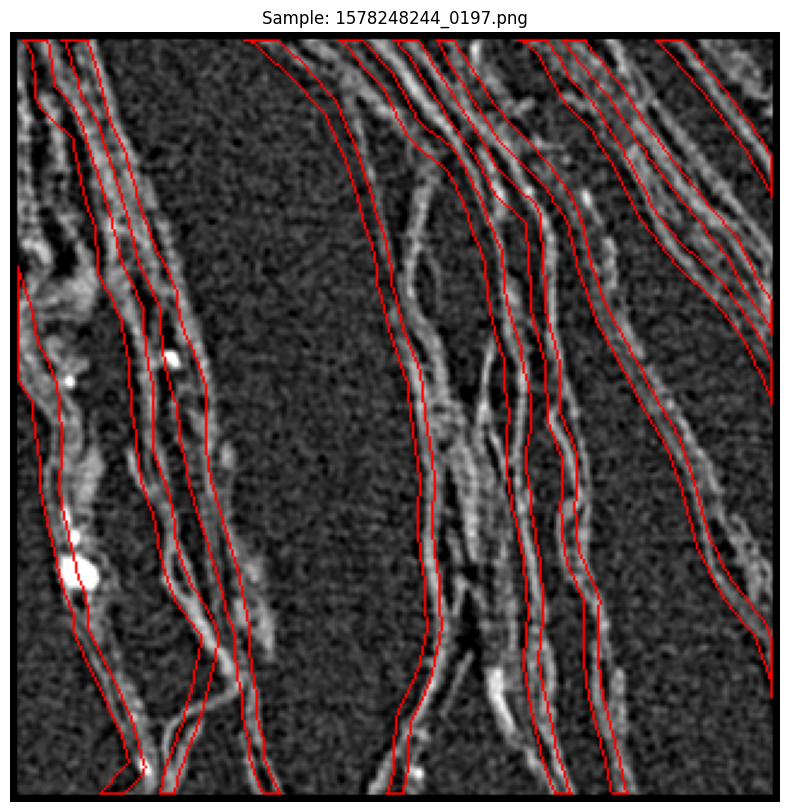

In [8]:
import random
import matplotlib.pyplot as plt

def visualize_yolo_sample(img_path, lbl_path):
    """
    Loads the image and YOLO labels, draws the polygons, and displays the result.
    Takes direct paths to image and label files.
    """
    # Load image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    filename = os.path.basename(img_path)
    print(f"Annotation: {lbl_path}")

    with open(lbl_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        coords = list(map(float, parts[1:]))
        # Rescale coordinates
        points = []
        for i in range(0, len(coords), 2):
            px = int(coords[i] * w)
            py = int(coords[i+1] * h)
            points.append([px, py])
        points = np.array(points, dtype=np.int32).reshape((-1, 1, 2))
        # Draw polygon
        cv2.polylines(image, [points], isClosed=True, color=(255, 0, 0), thickness=1)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Sample: {filename}")
    plt.axis('off')
    plt.show()

# Logic to pick a random file
img_dir = os.path.join(DATASET_DIR, 'images', 'train')
lbl_dir = os.path.join(DATASET_DIR, 'labels', 'train')

files = [f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')]
random_file = random.choice(files)
img_path_sample = os.path.join(img_dir, random_file)
lbl_file_sample = os.path.splitext(random_file)[0] + '.txt'
lbl_path_sample = os.path.join(lbl_dir, lbl_file_sample)

visualize_yolo_sample(img_path_sample, lbl_path_sample)

In [9]:
import yaml

# Define the configuration for the YOLO dataset
yaml_content = {
    'path': os.path.abspath(DATASET_DIR), # Absolute path to the dataset root
    'train': 'images/train',              # Relative path to training images
    'val': 'images/val',                  # Relative path to validation images
    'names': {
        0: 'surface'                      # Class mapping
    }
}

# Save to dataset.yaml
yaml_path = 'dataset.yaml' # Save in current directory for easy access

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"Dataset YAML created at: {os.path.abspath(yaml_path)}")
print("\nFile Content:")
print(yaml.dump(yaml_content, sort_keys=False))

Dataset YAML created at: /kaggle/working/dataset.yaml

File Content:
path: /kaggle/working/vesuvius_yolo_dataset
train: images/train
val: images/val
names:
  0: surface



## 🏋️ Training

Main training pipeline...

In [10]:
from ultralytics import YOLO

# Load a model
model = YOLO("/kaggle/input/yolo11-seg/pytorch/default/1/yolo11m-seg.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
# Train the model
print("Starting training...")
results = model.train(
    data="dataset.yaml",  # path to dataset YAML created earlier
    epochs=50,            # number of training epochs
    imgsz=320,            # image size (matches our slice size)
    batch=12,             # batch size
    name="vesuvius_yolo11" # save results to runs/detect/vesuvius_yolo11
)

Starting training...
Ultralytics 8.3.231 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/yolo11-seg/pytorch/default/1/yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=vesuvius_yolo11, nbs=64, nms=False, opset=None, optimize=False, optimizer=

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1397      14528      0.858      0.822      0.869      0.592      0.522      0.448      0.343      0.104
Speed: 0.1ms preprocess, 5.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /kaggle/working/runs/segment/vesuvius_yolo11


runs/segment/vesuvius_yolo11/BoxF1_curve.png


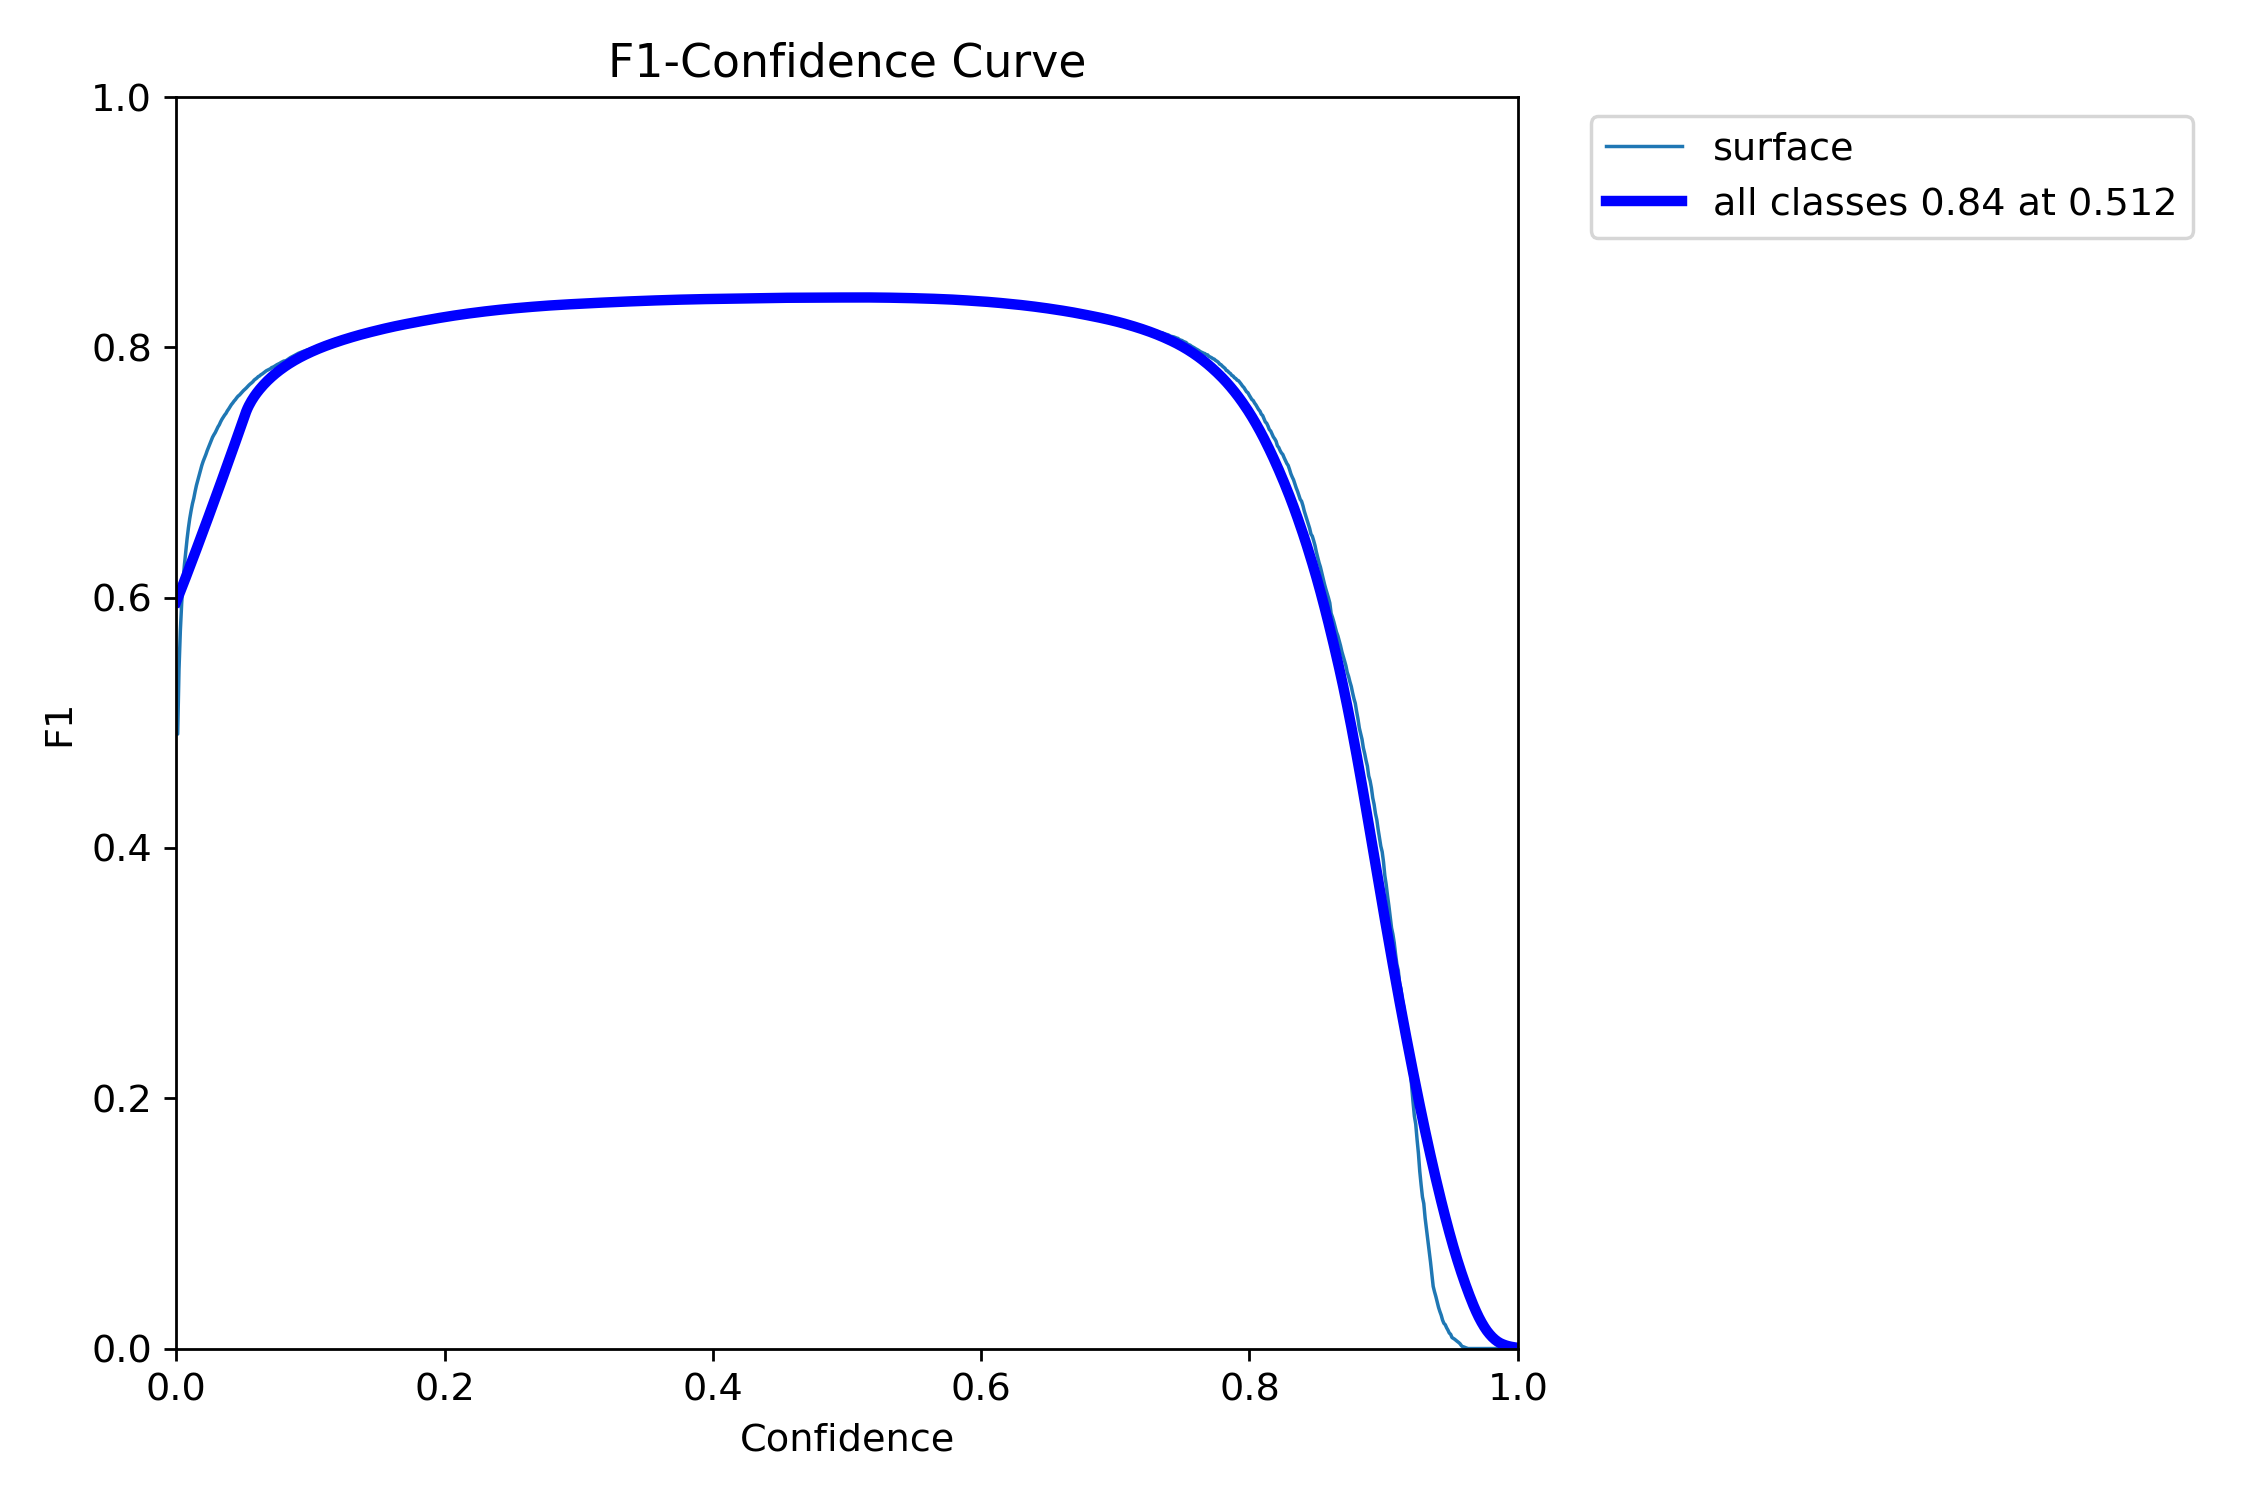

runs/segment/vesuvius_yolo11/BoxPR_curve.png


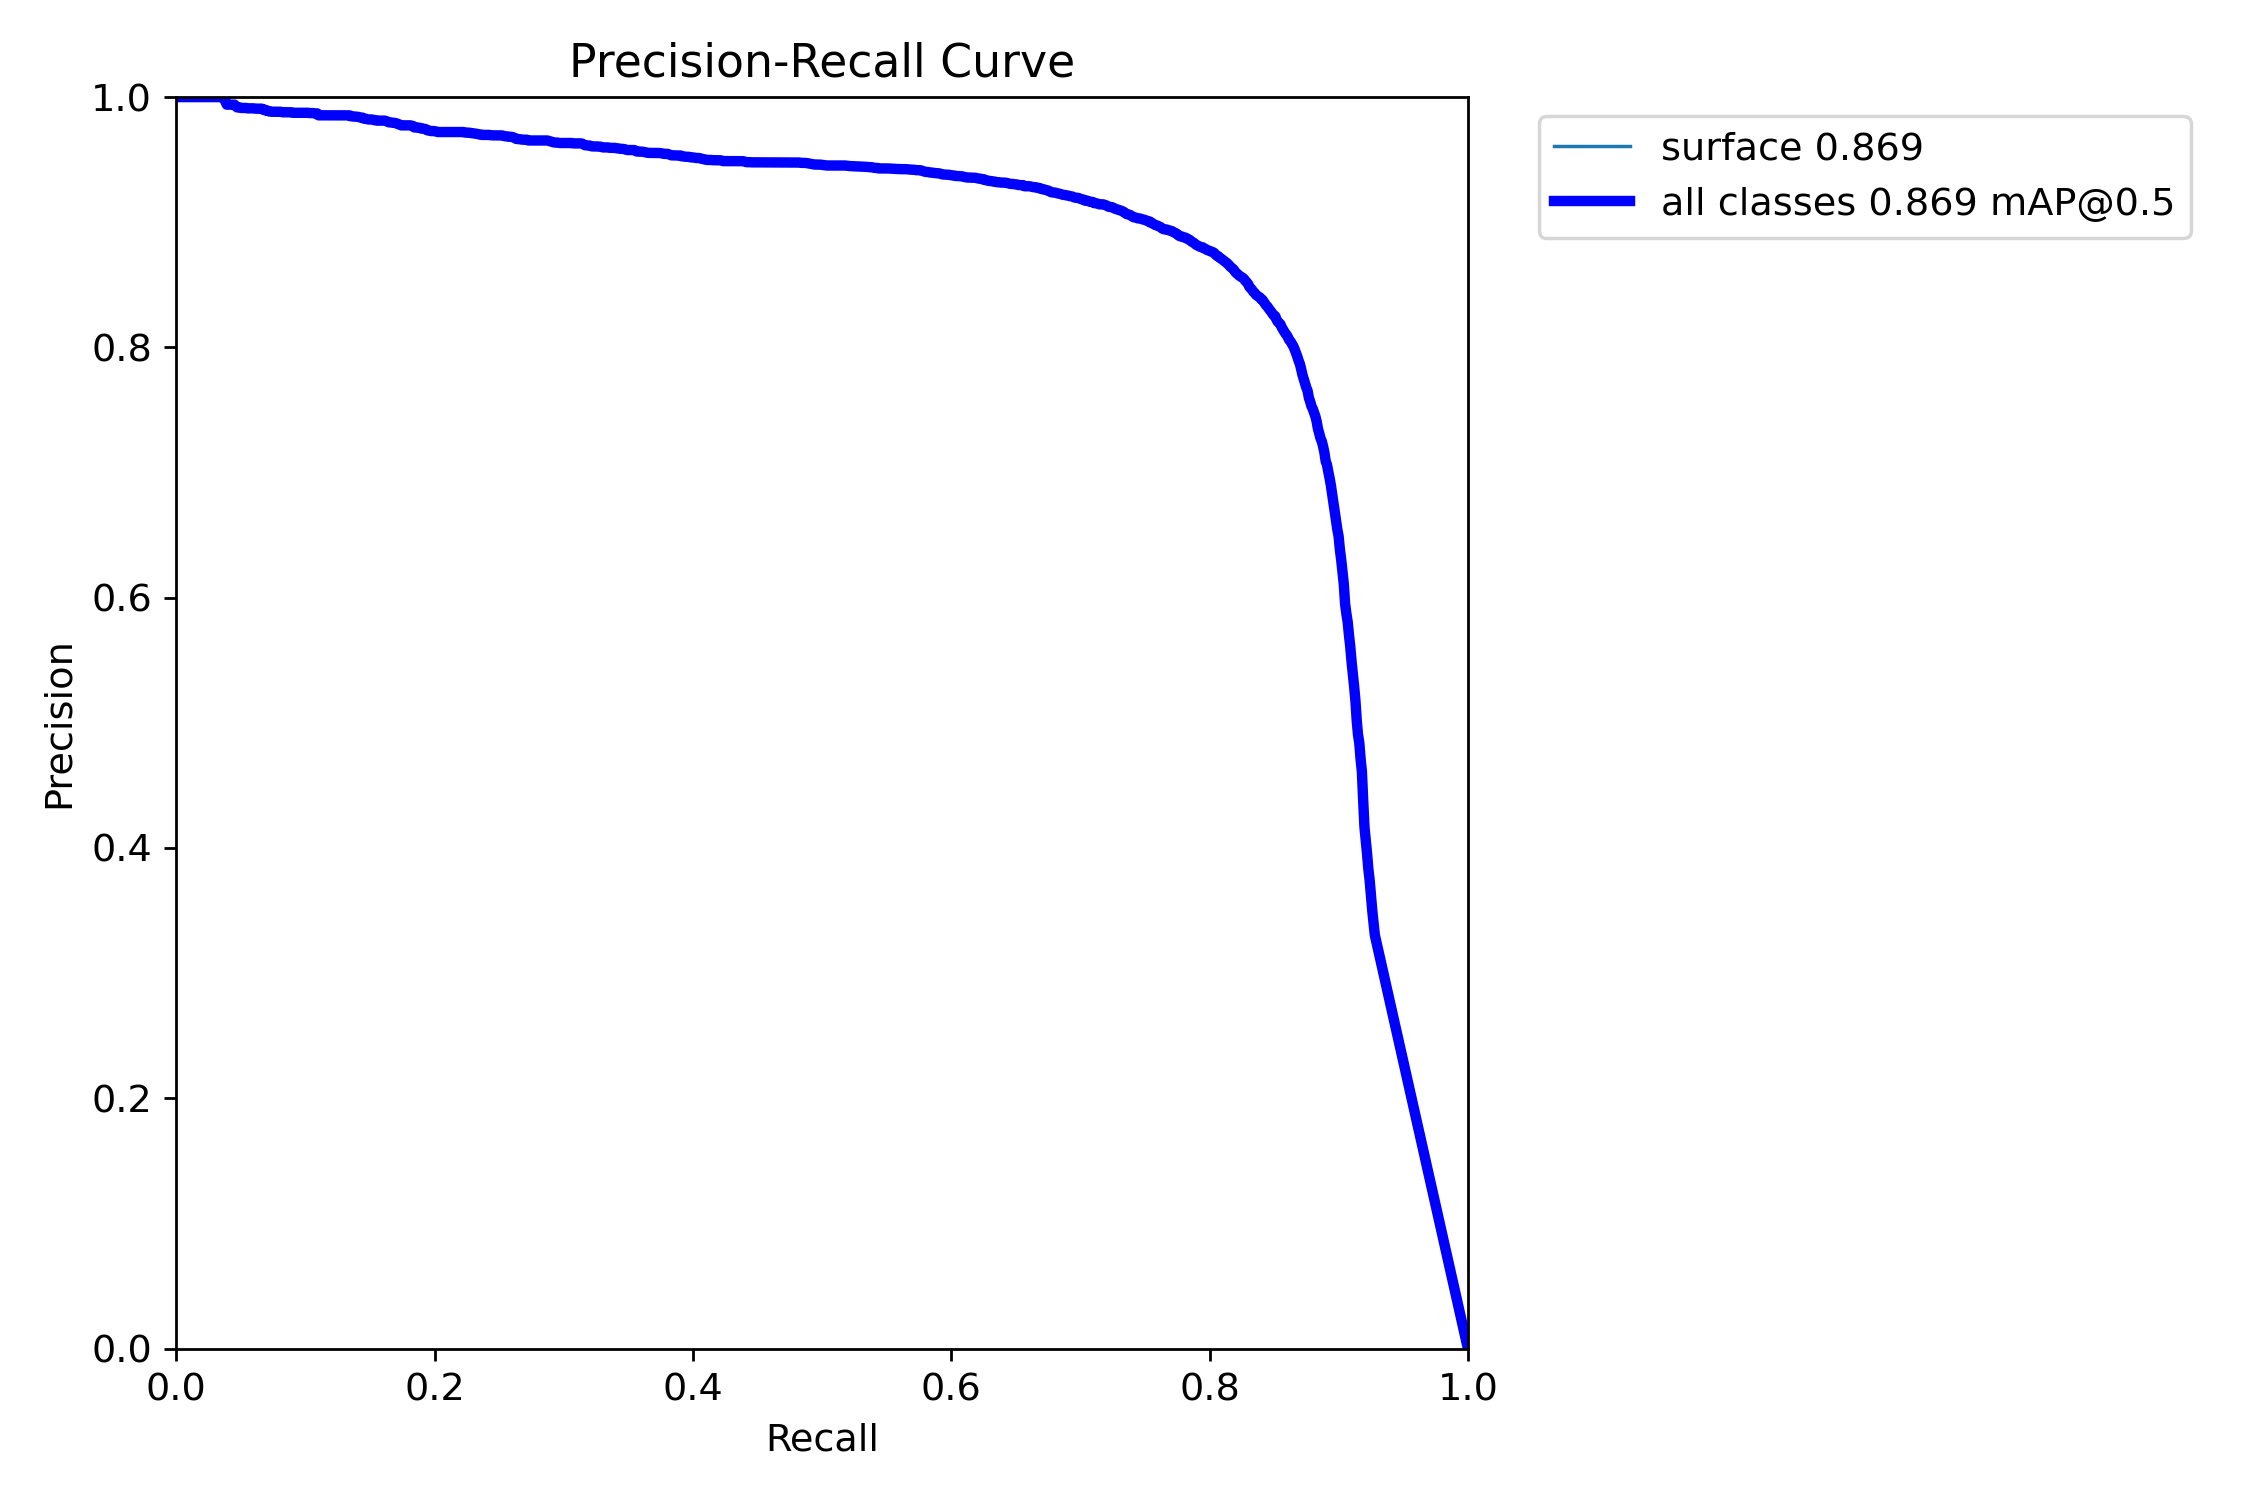

runs/segment/vesuvius_yolo11/BoxP_curve.png


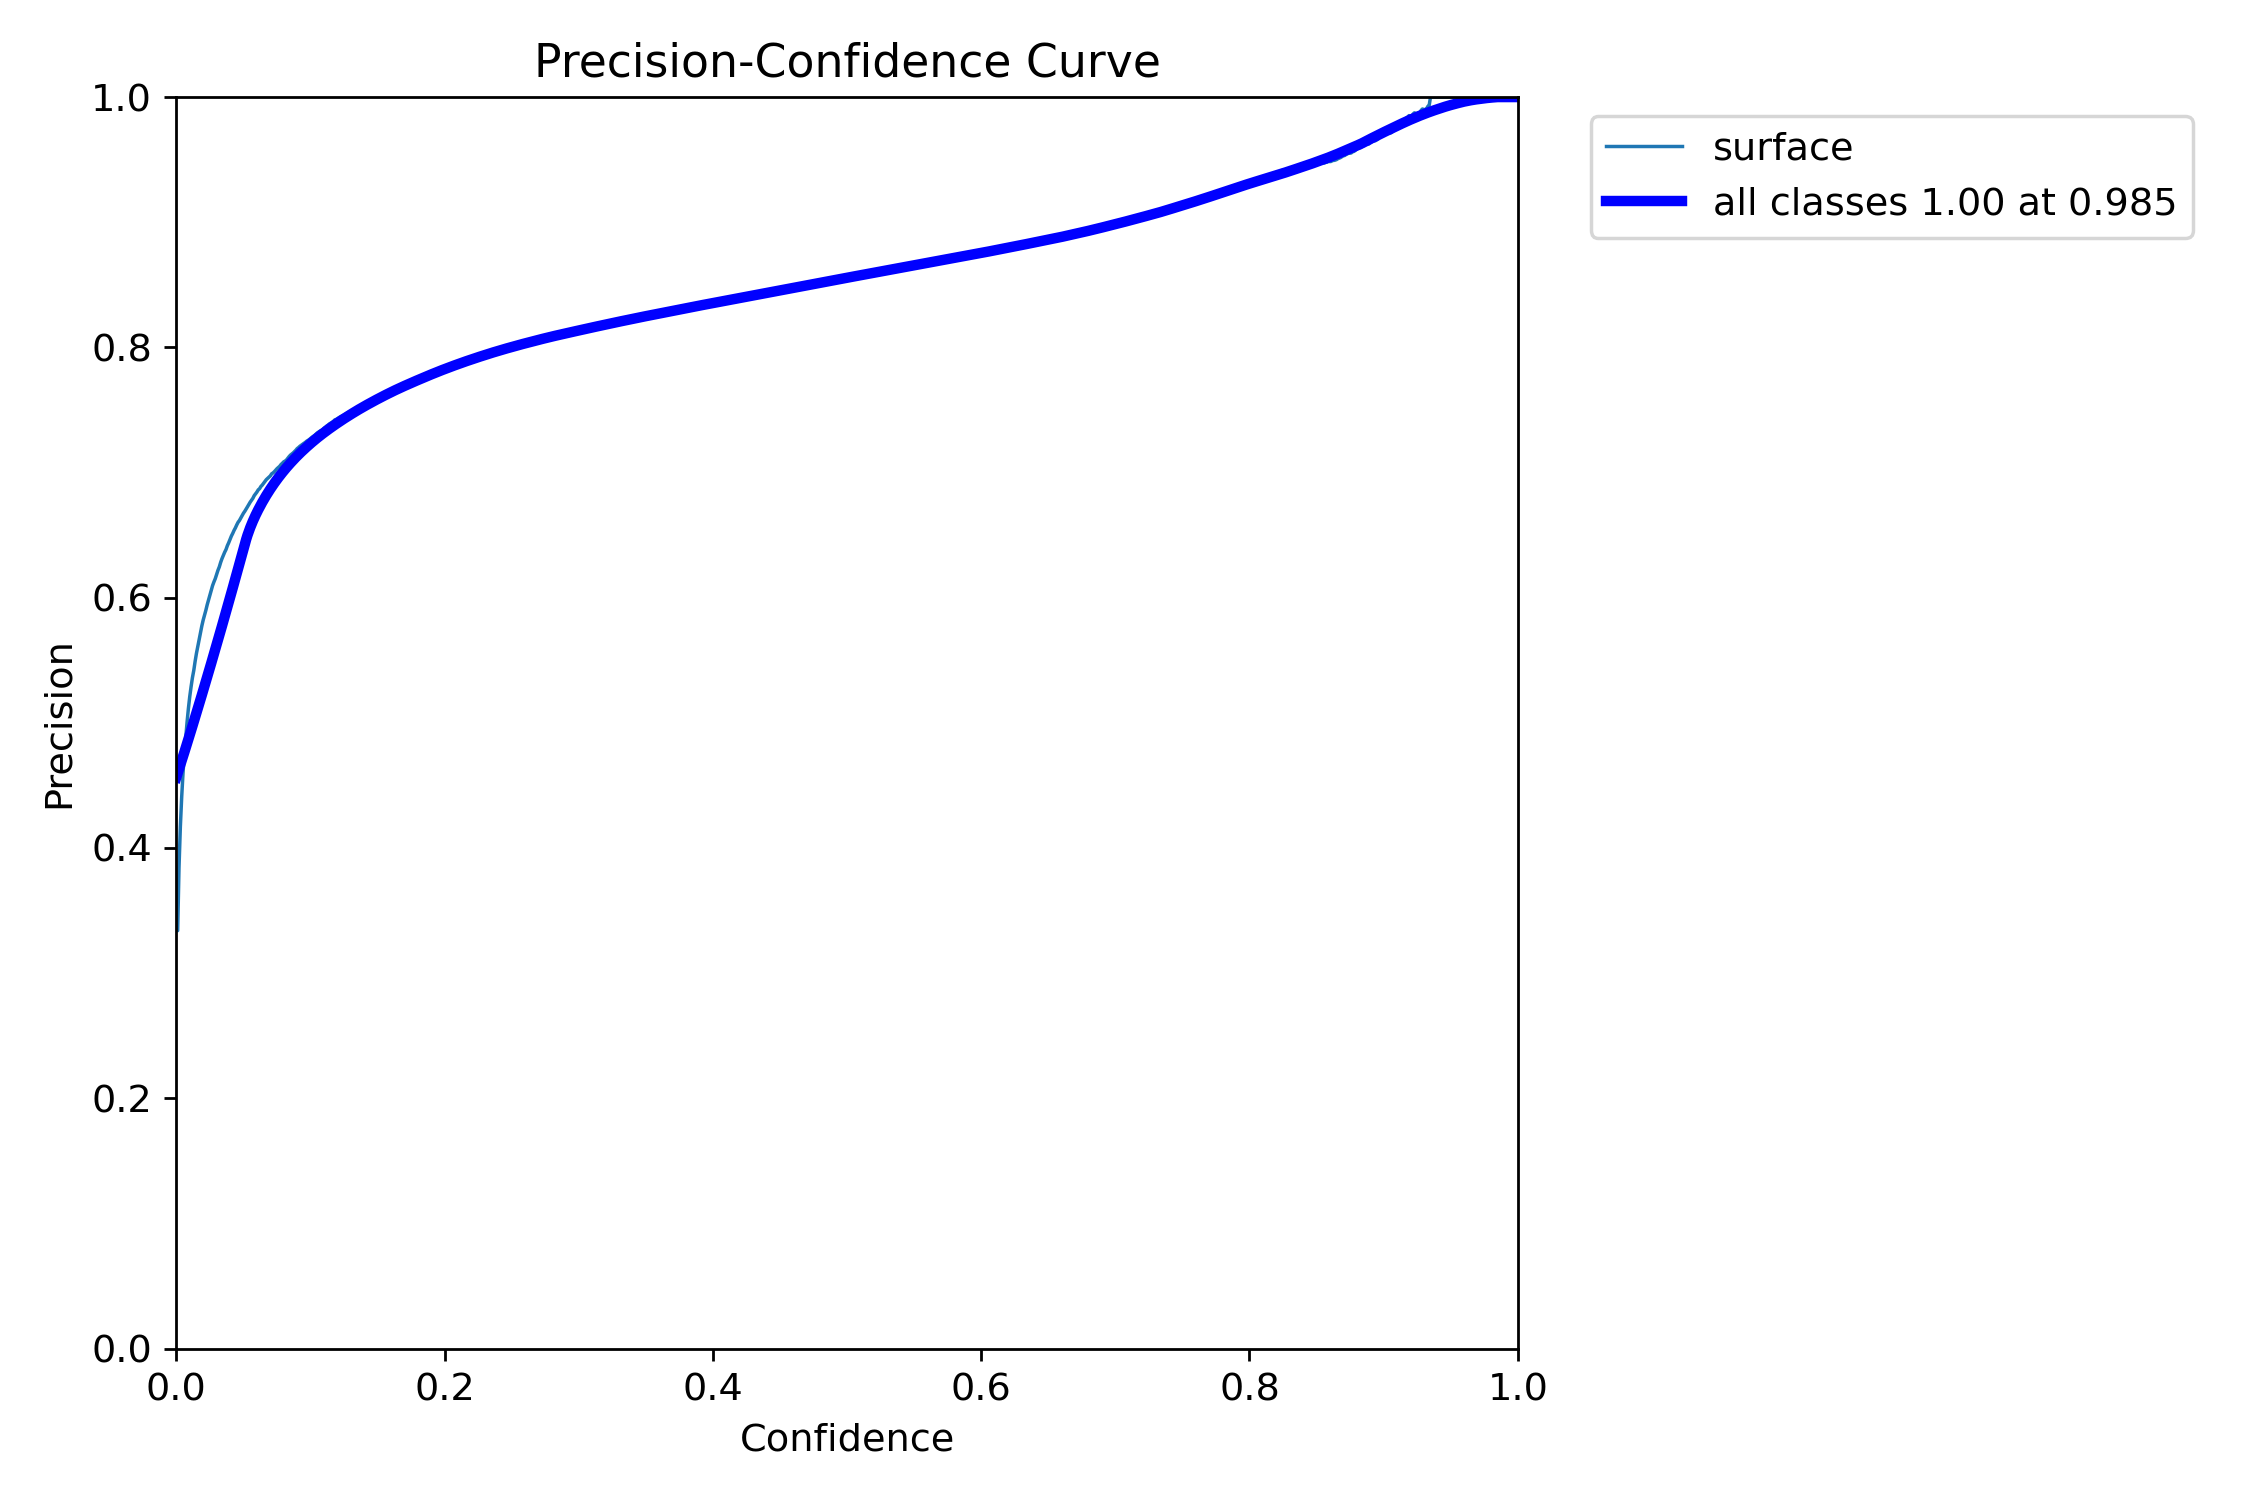

runs/segment/vesuvius_yolo11/BoxR_curve.png


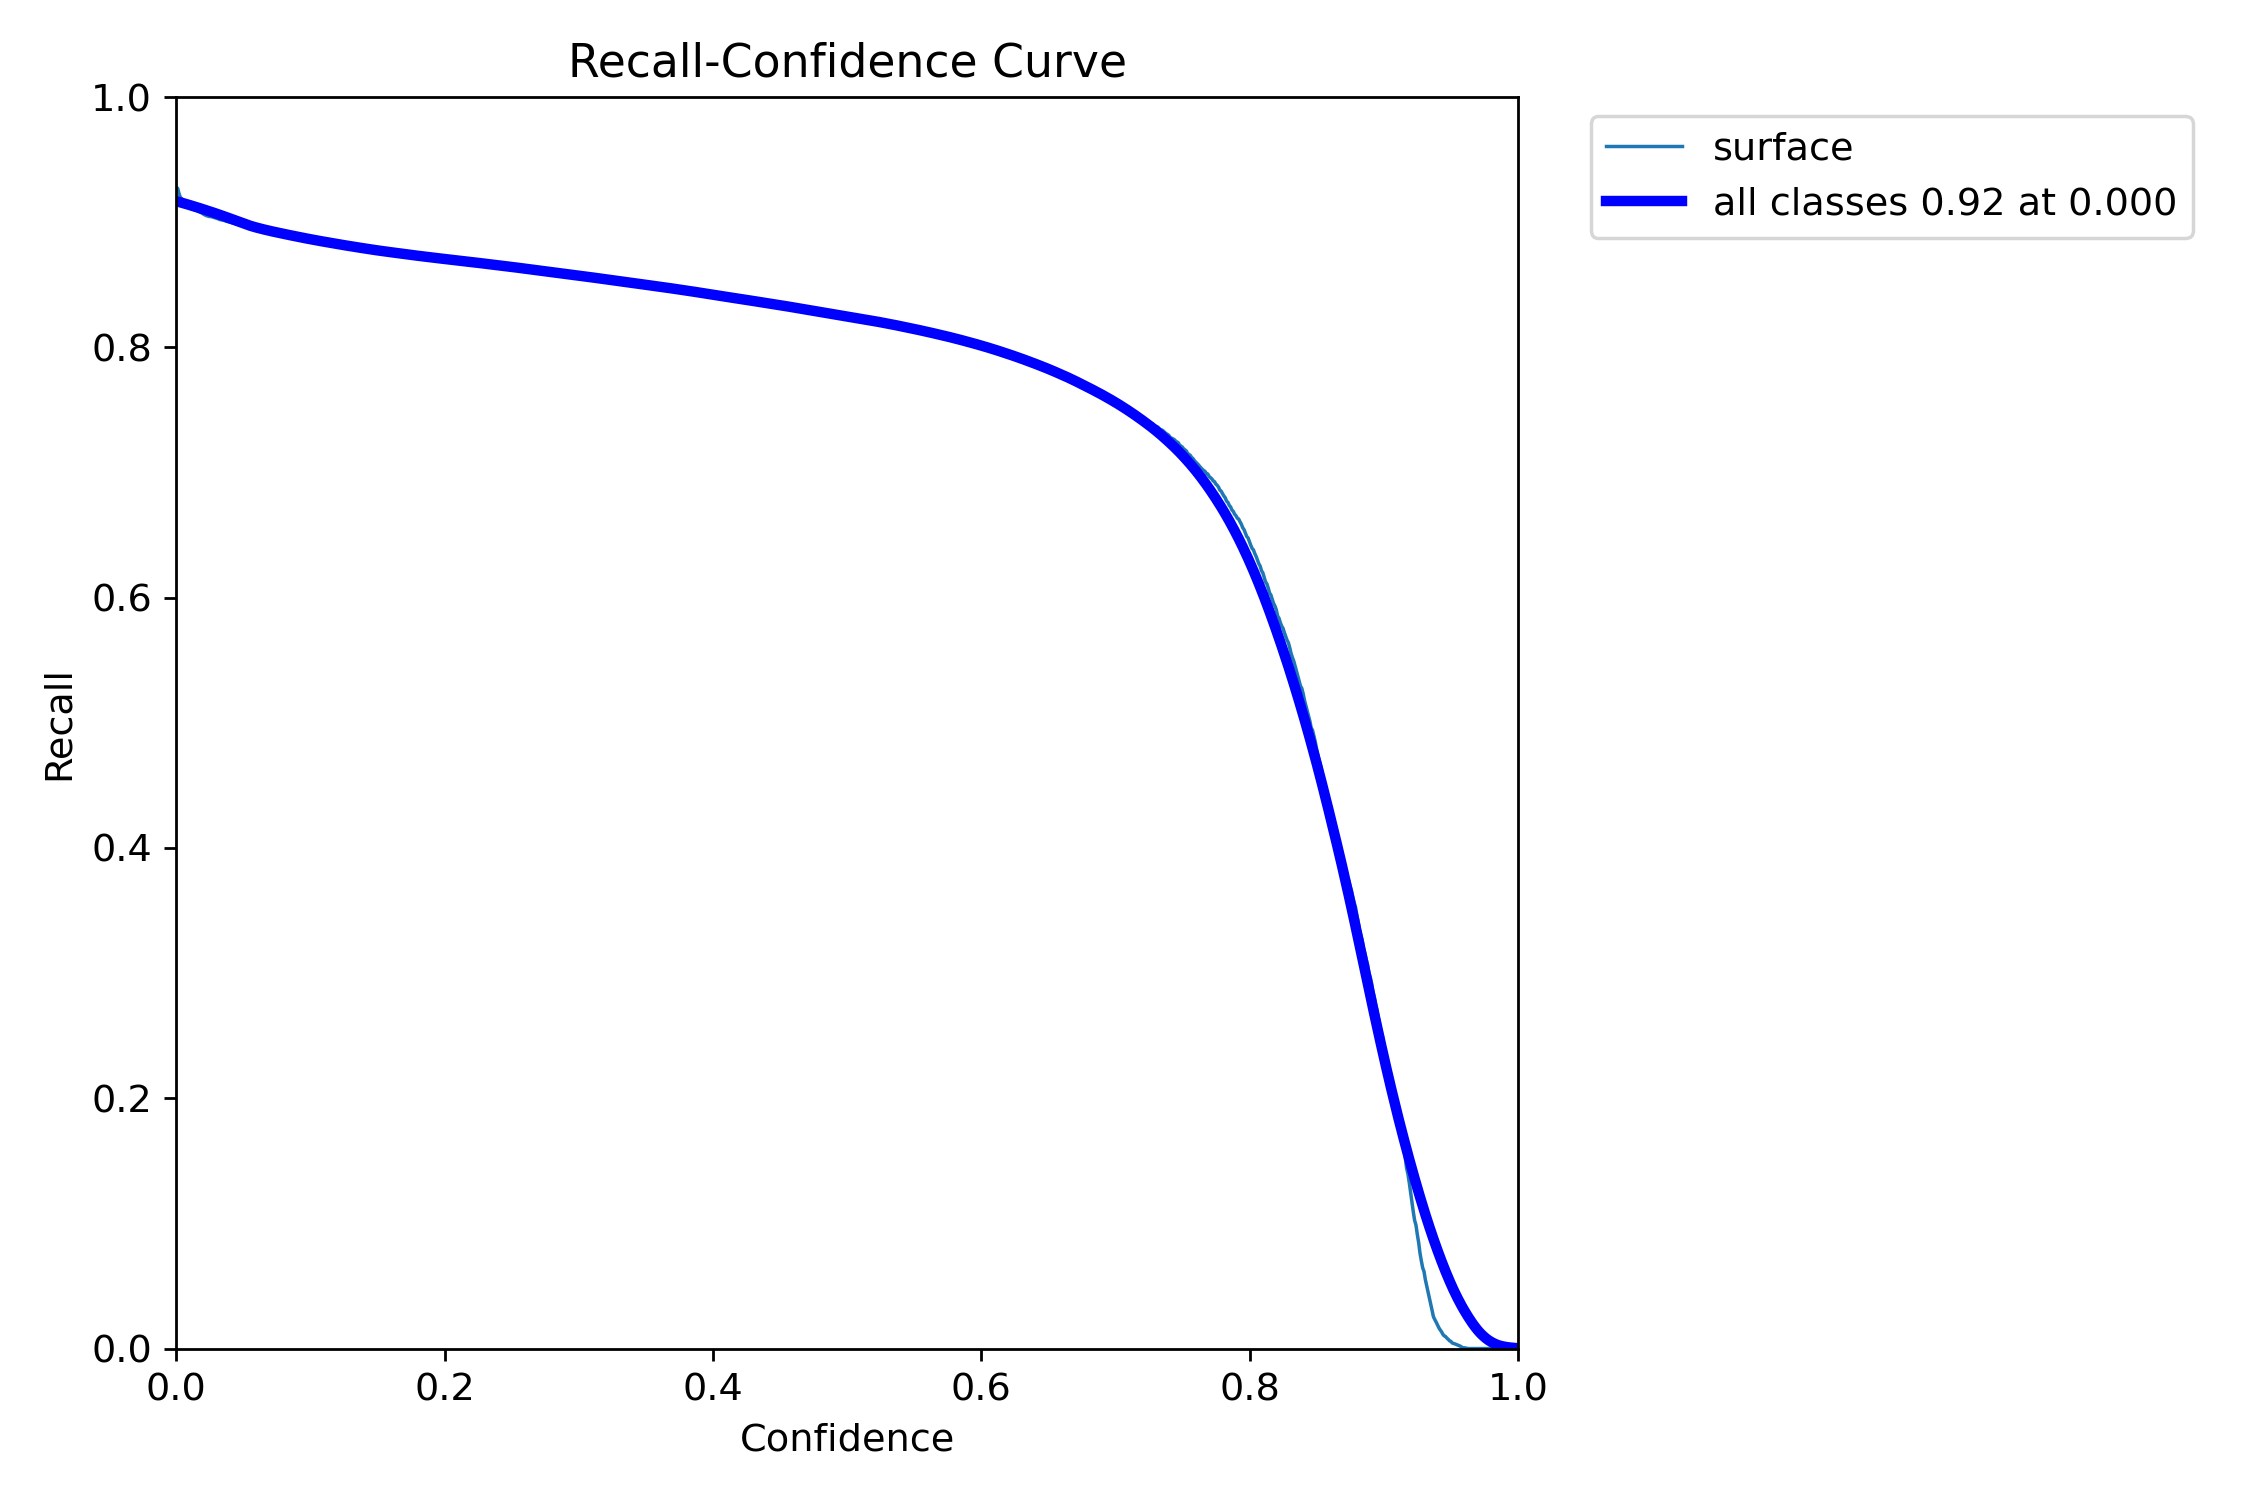

runs/segment/vesuvius_yolo11/MaskF1_curve.png


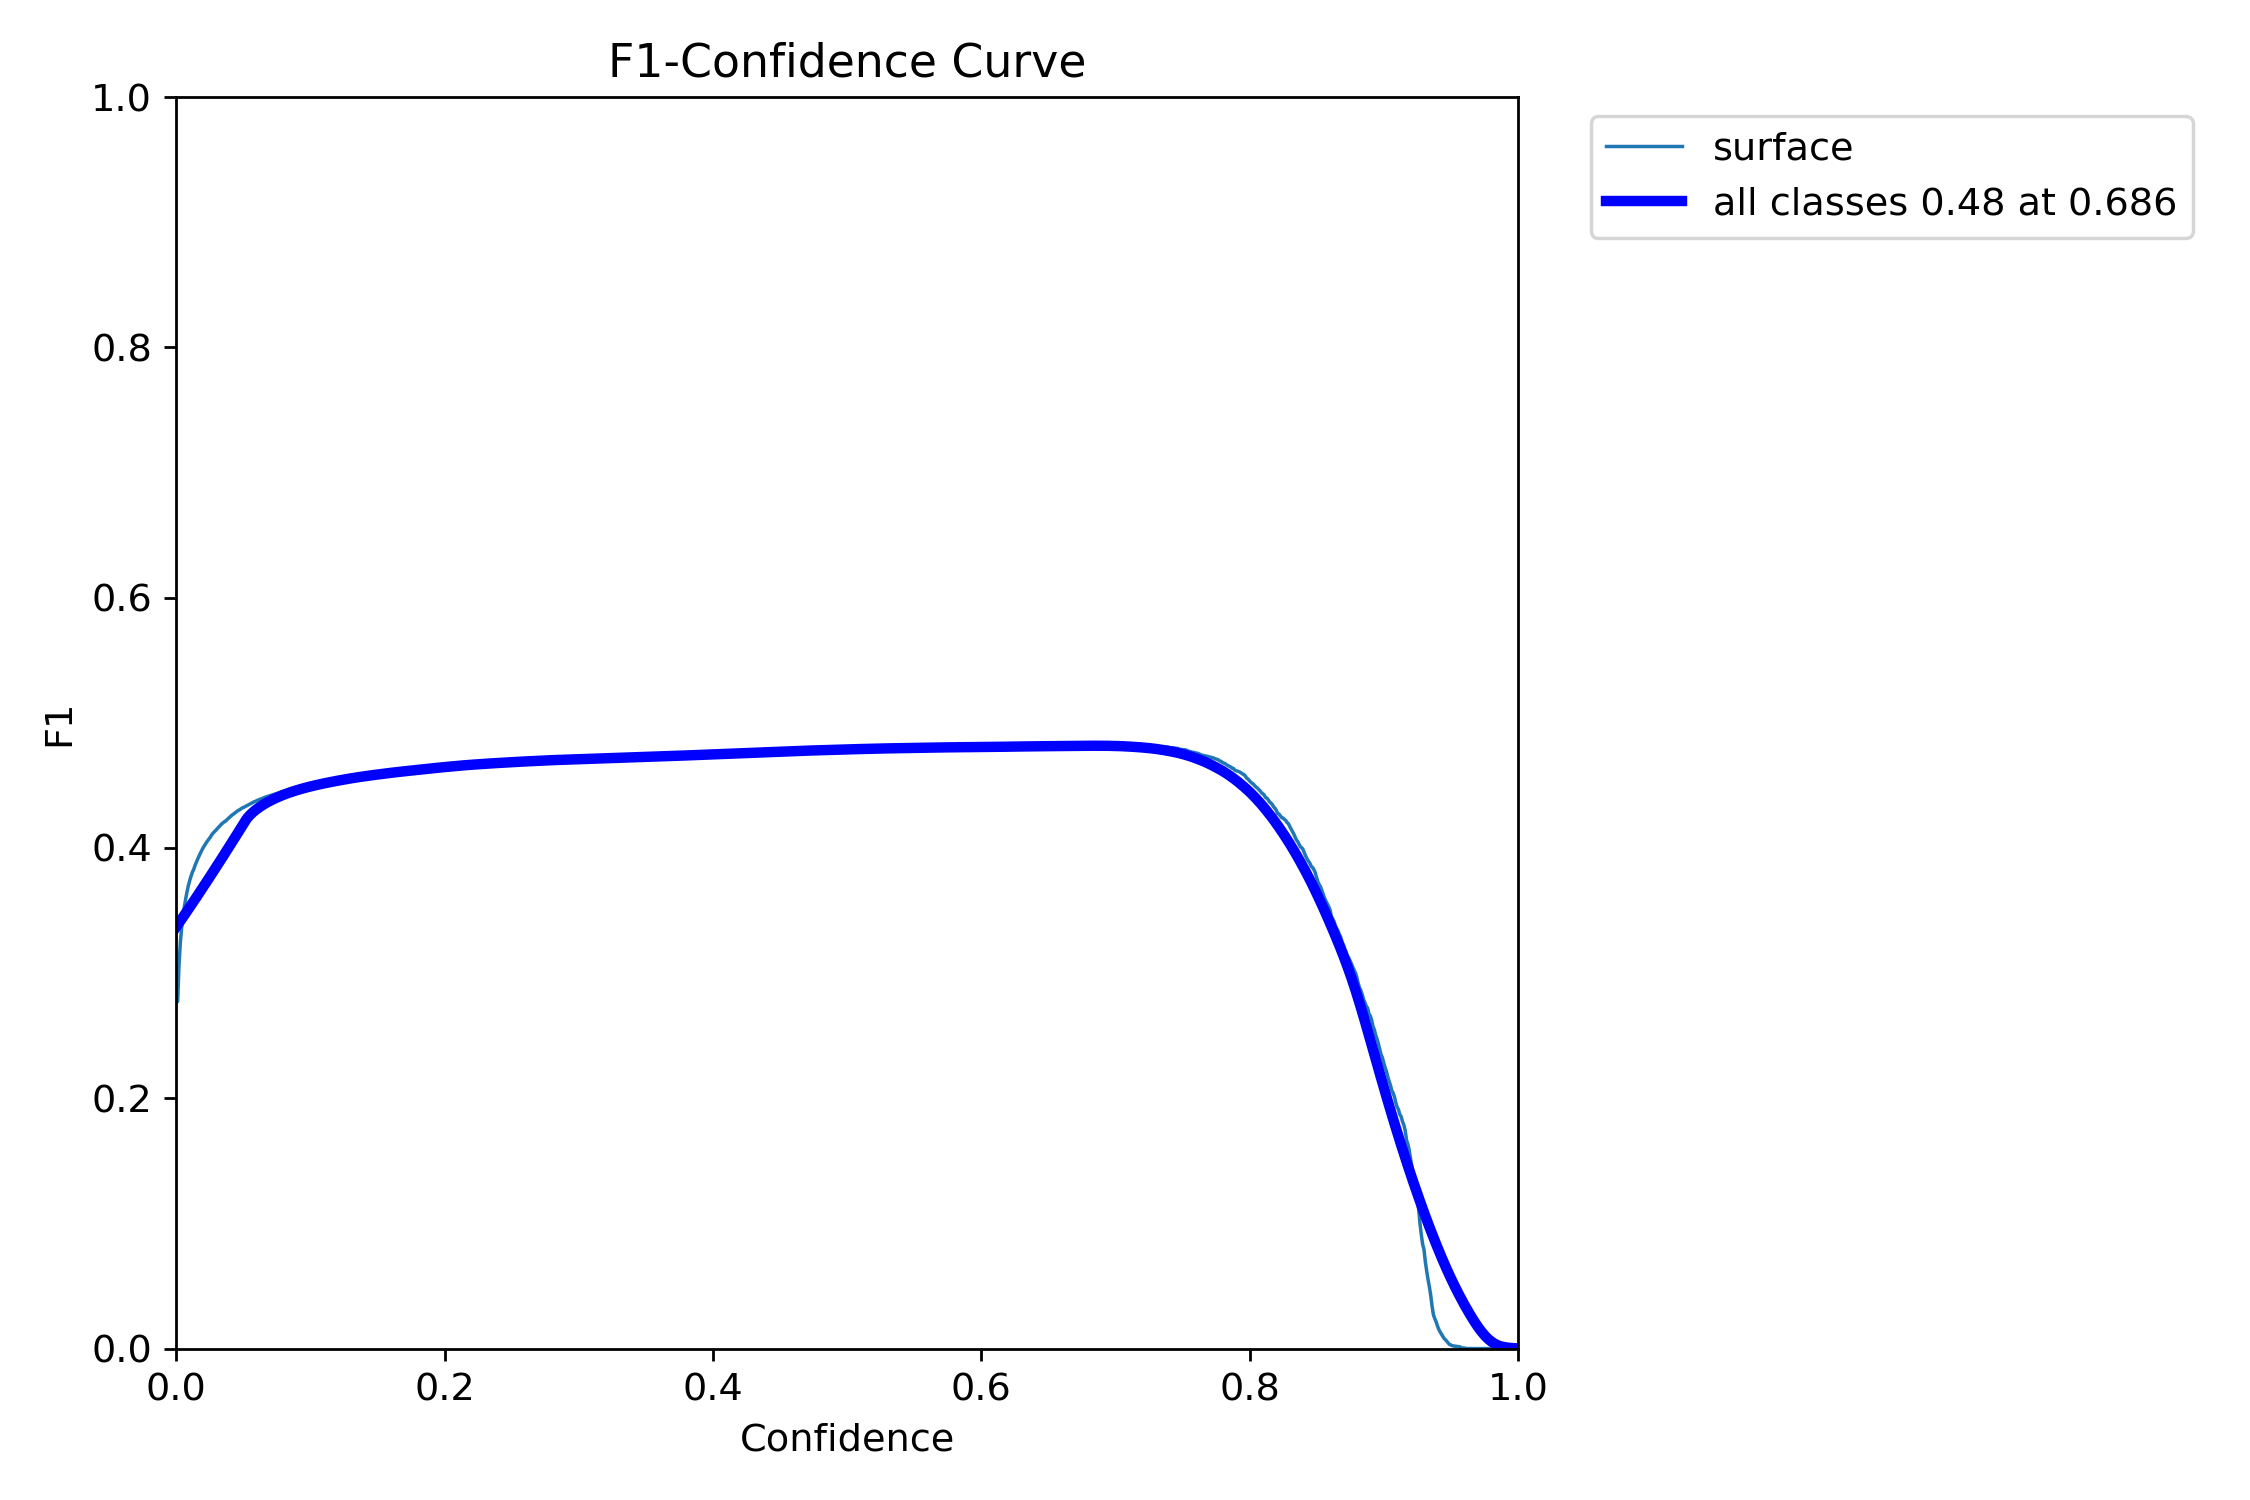

runs/segment/vesuvius_yolo11/MaskPR_curve.png


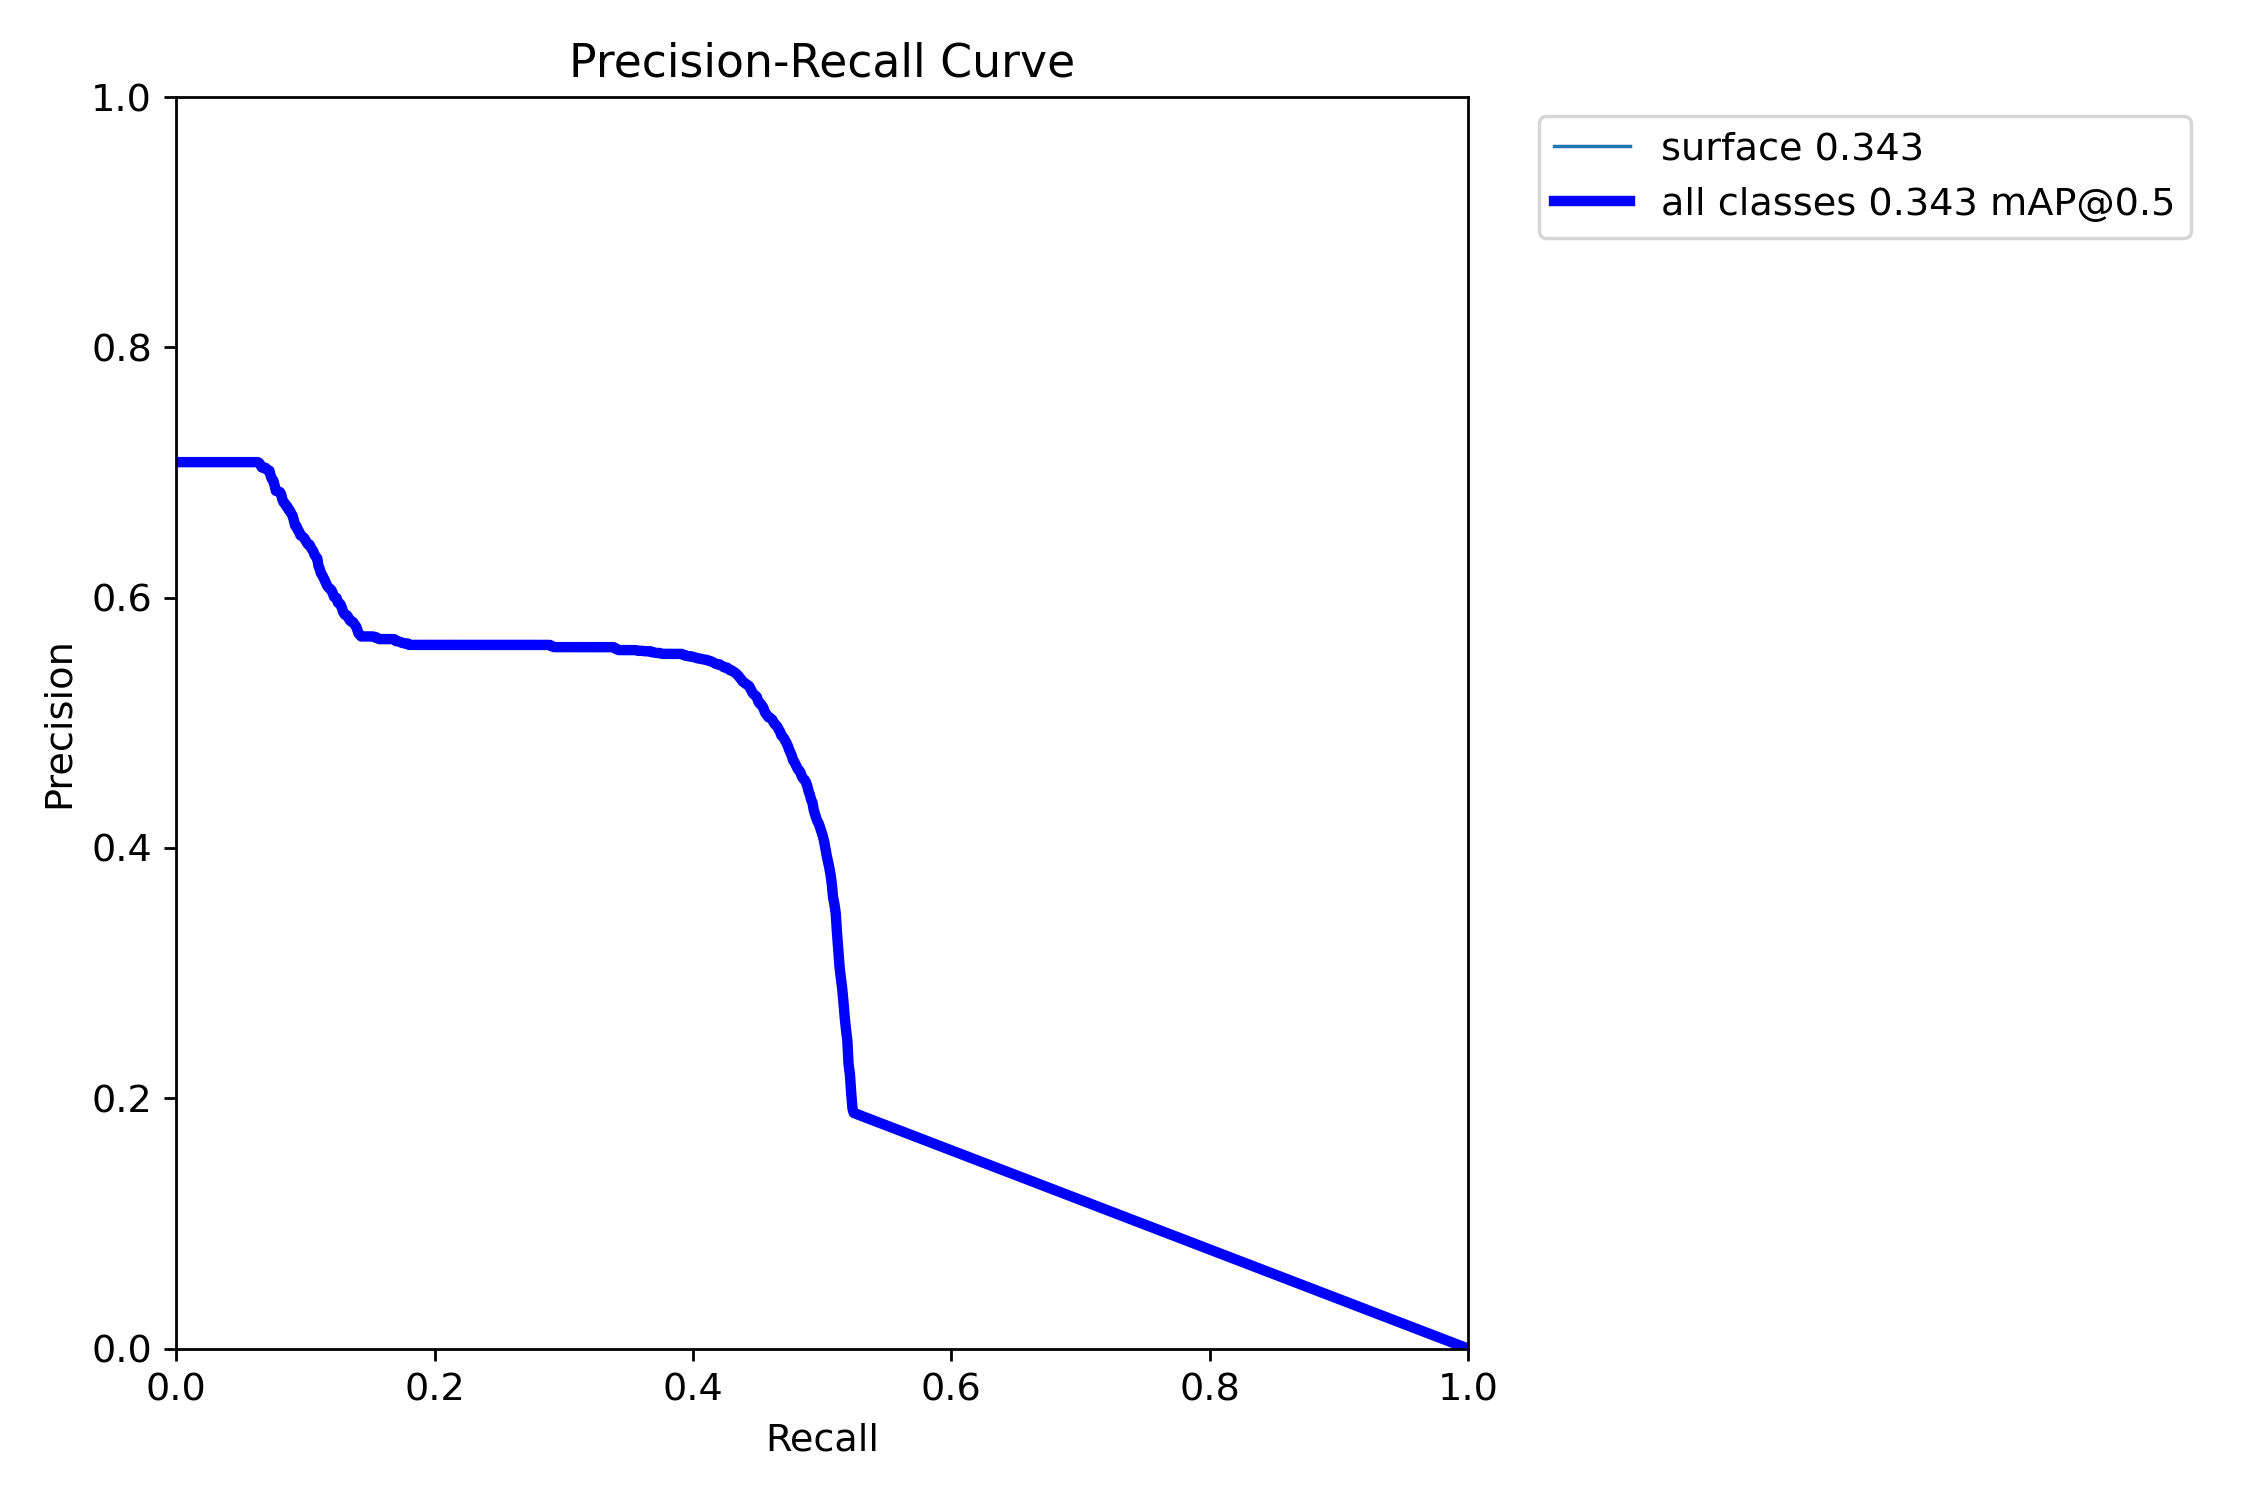

runs/segment/vesuvius_yolo11/MaskP_curve.png


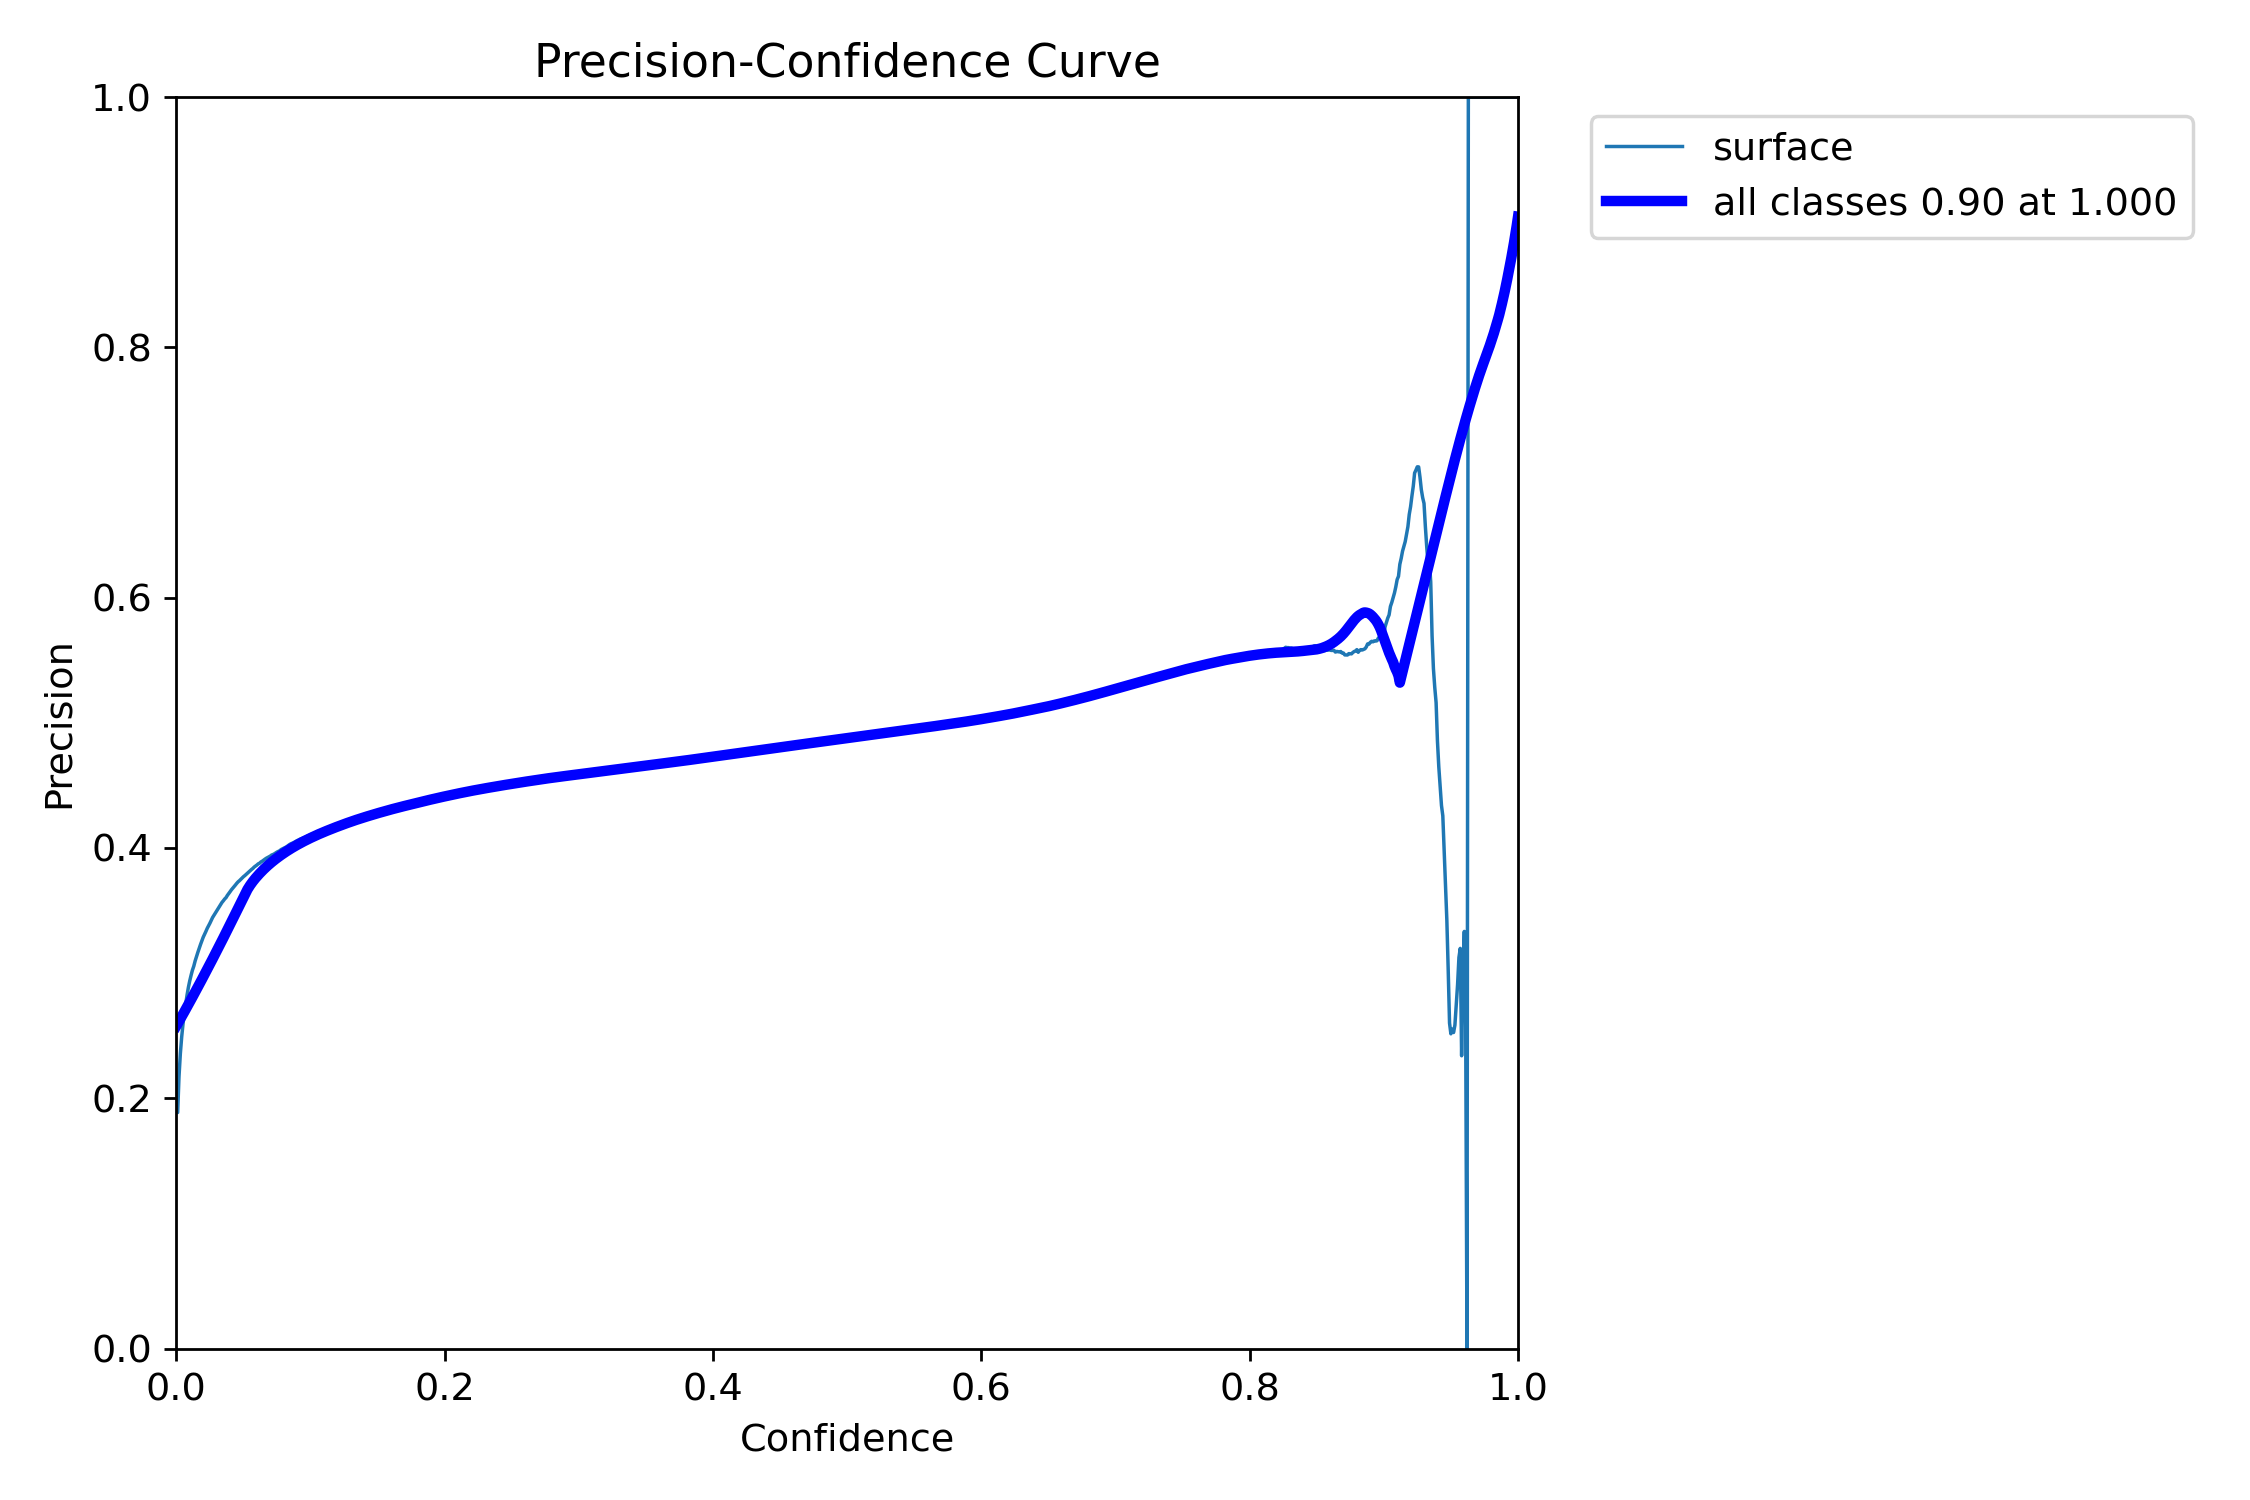

runs/segment/vesuvius_yolo11/MaskR_curve.png


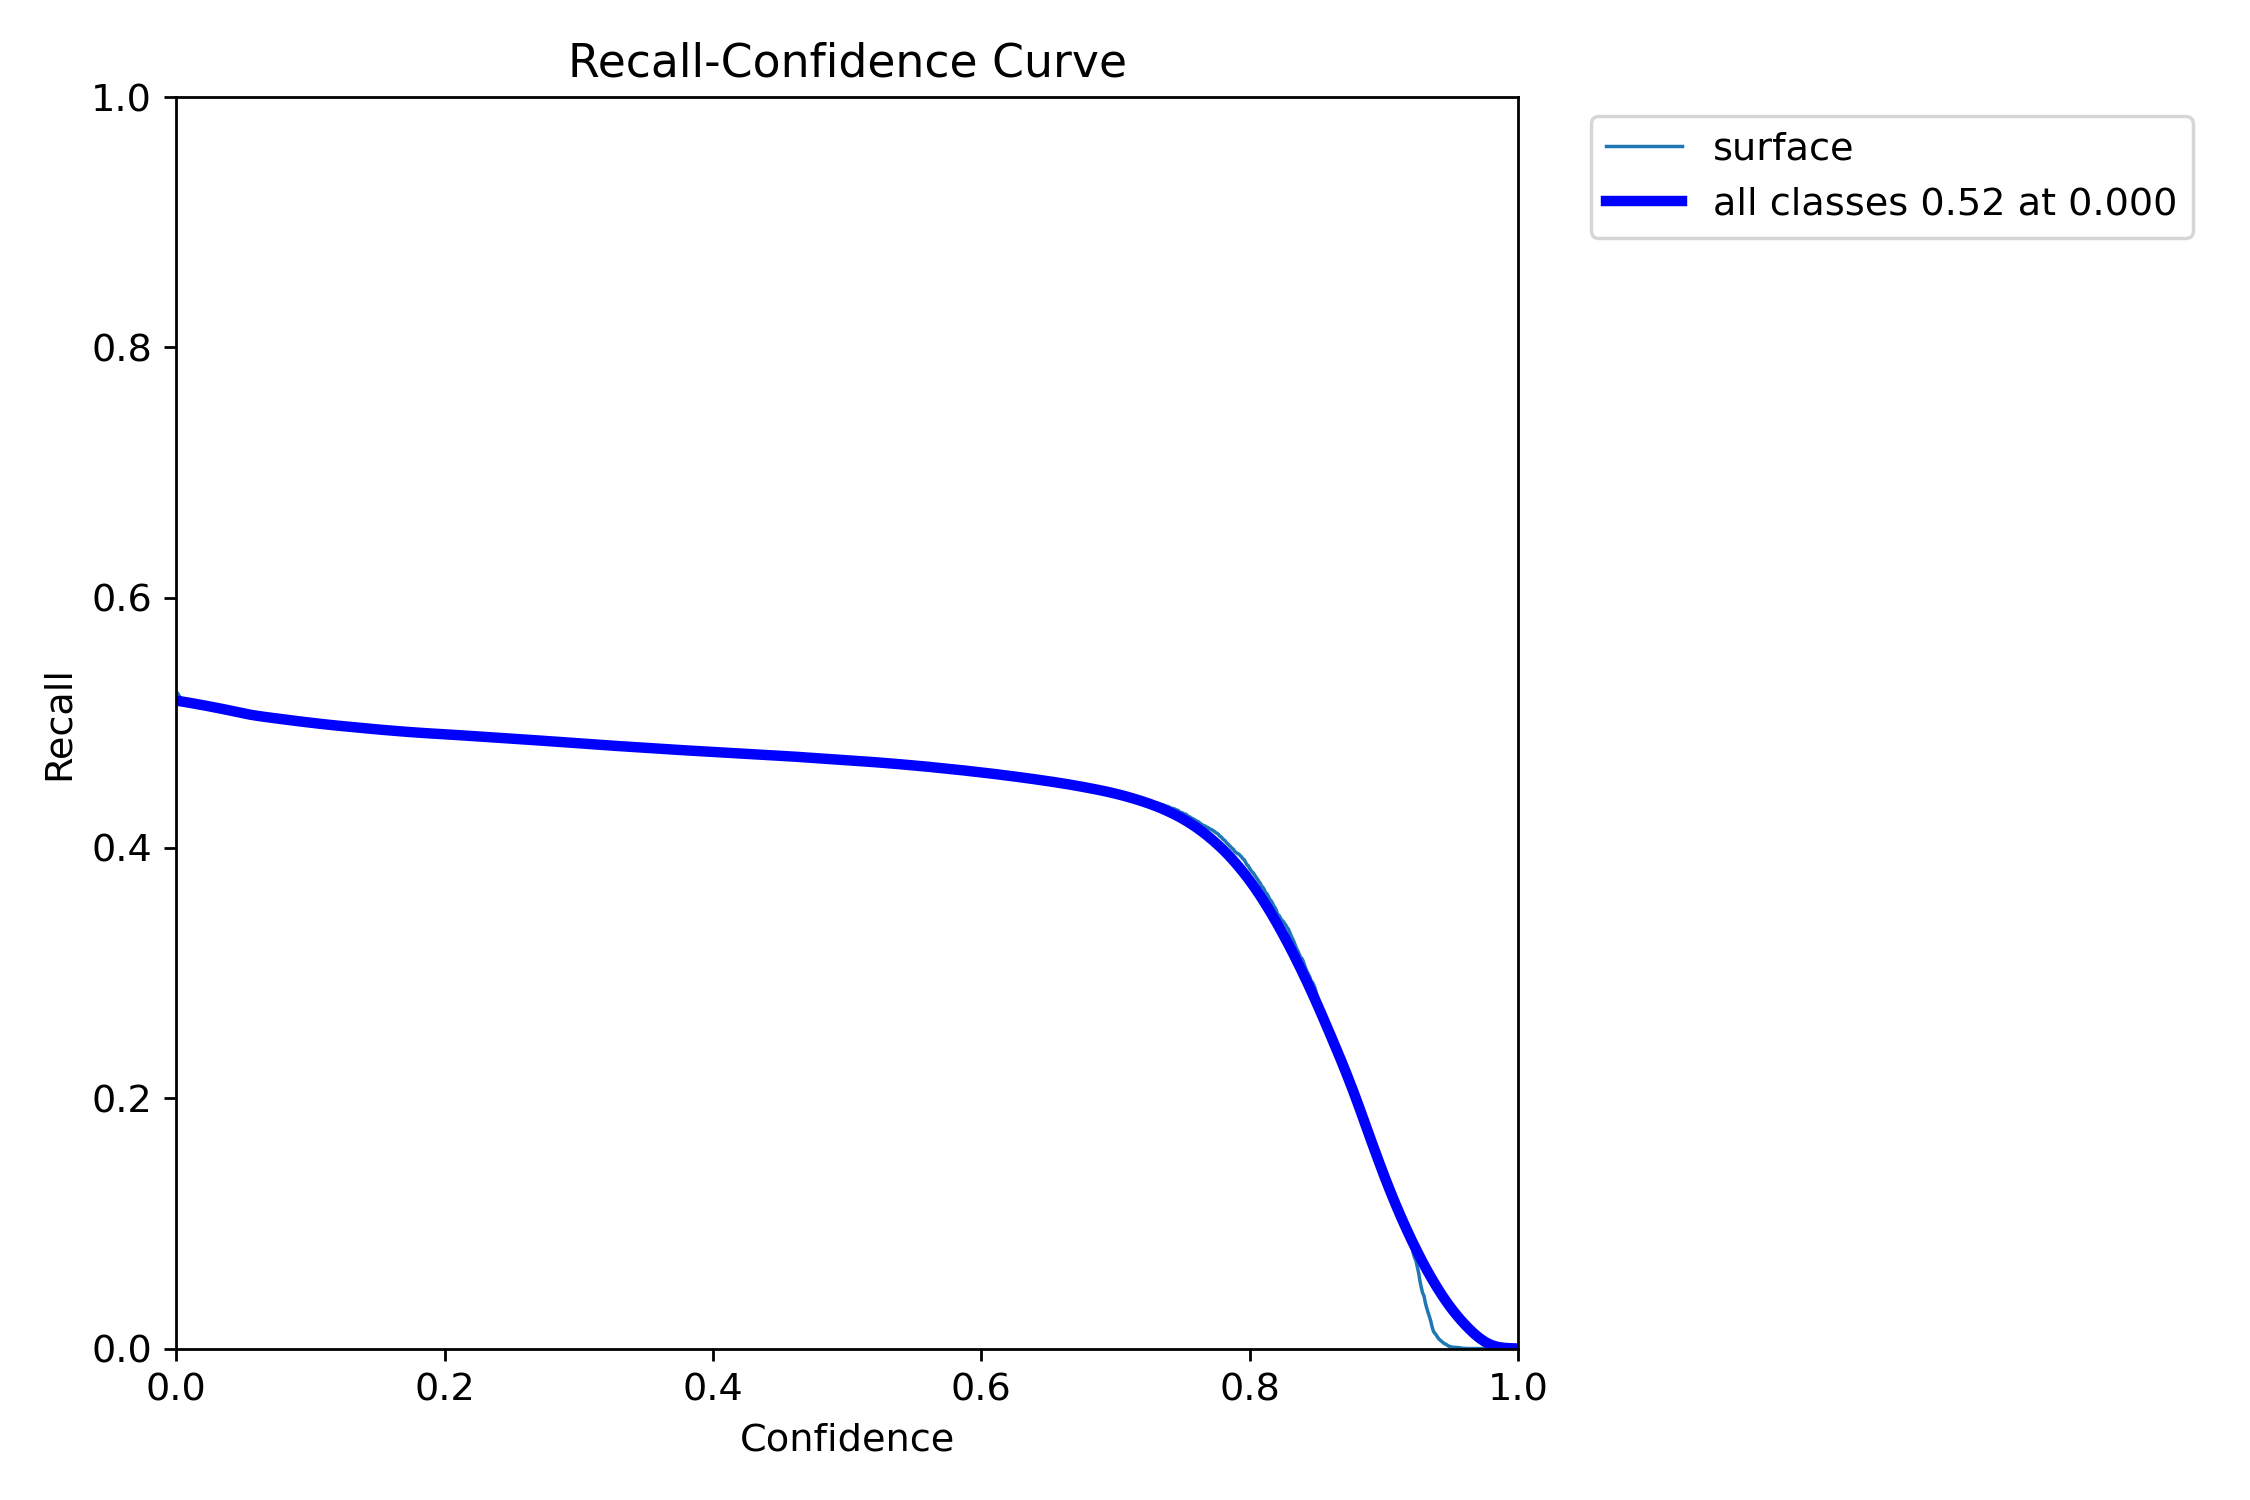

runs/segment/vesuvius_yolo11/confusion_matrix.png


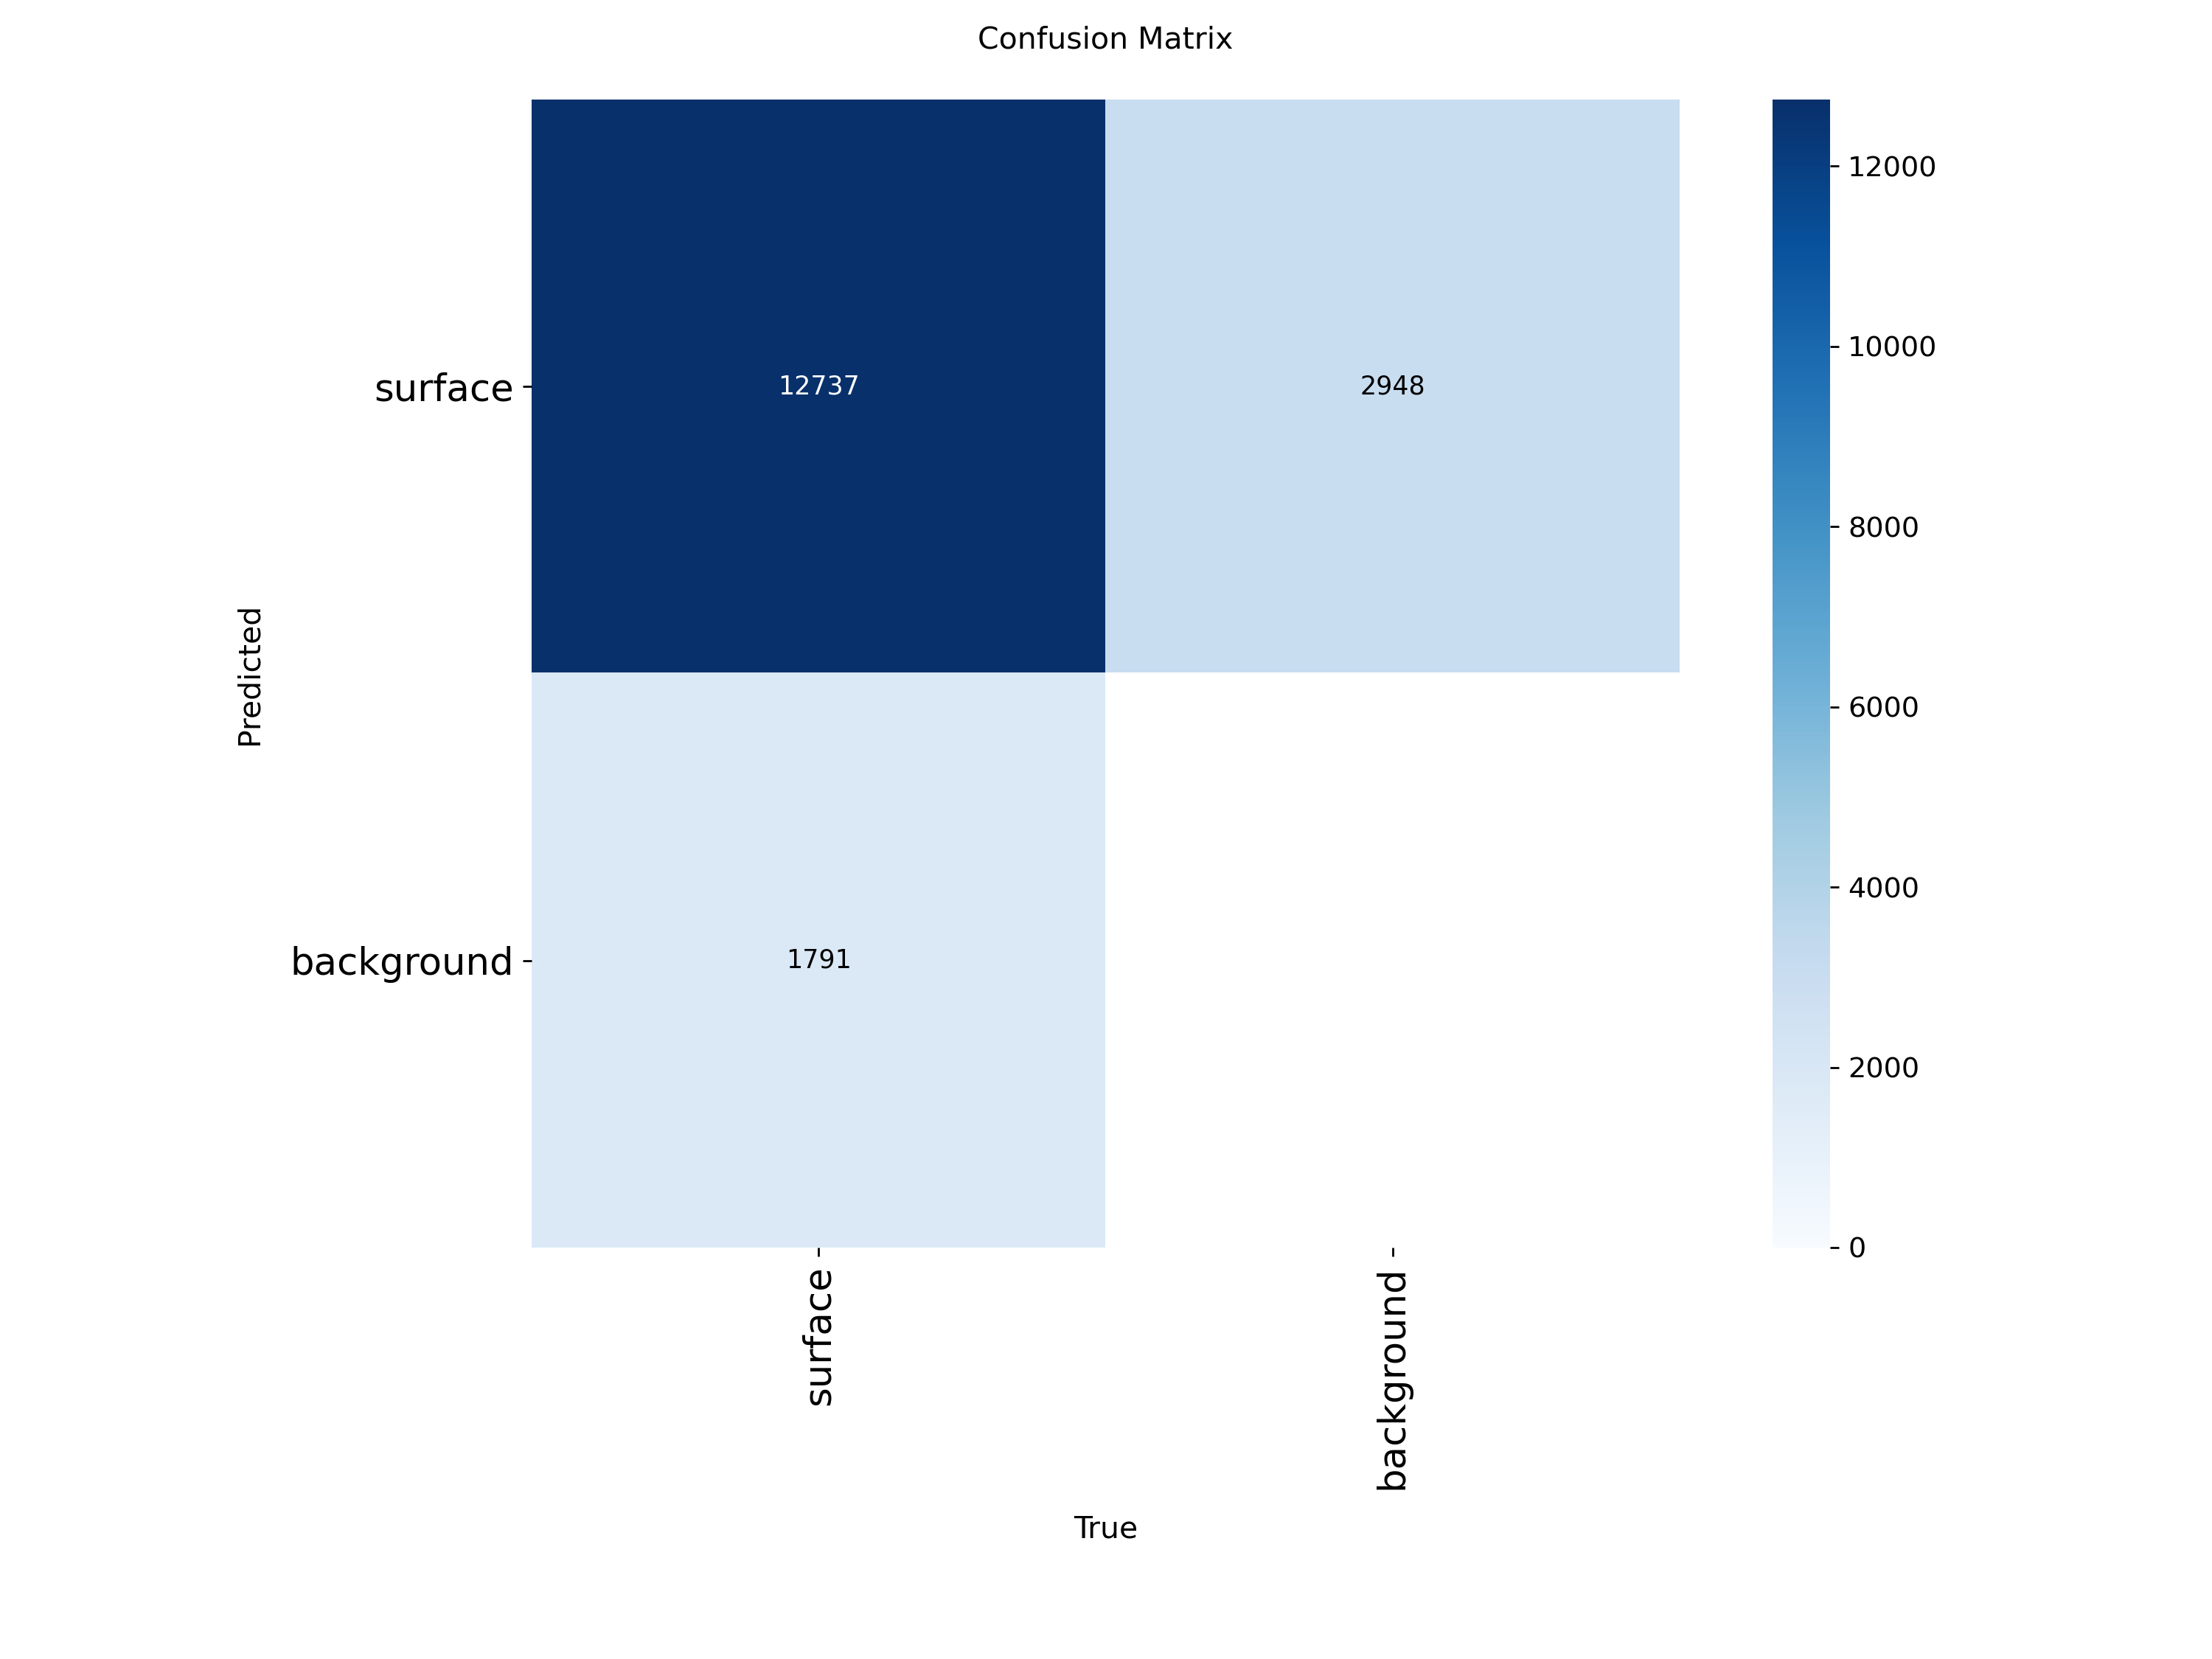

runs/segment/vesuvius_yolo11/confusion_matrix_normalized.png


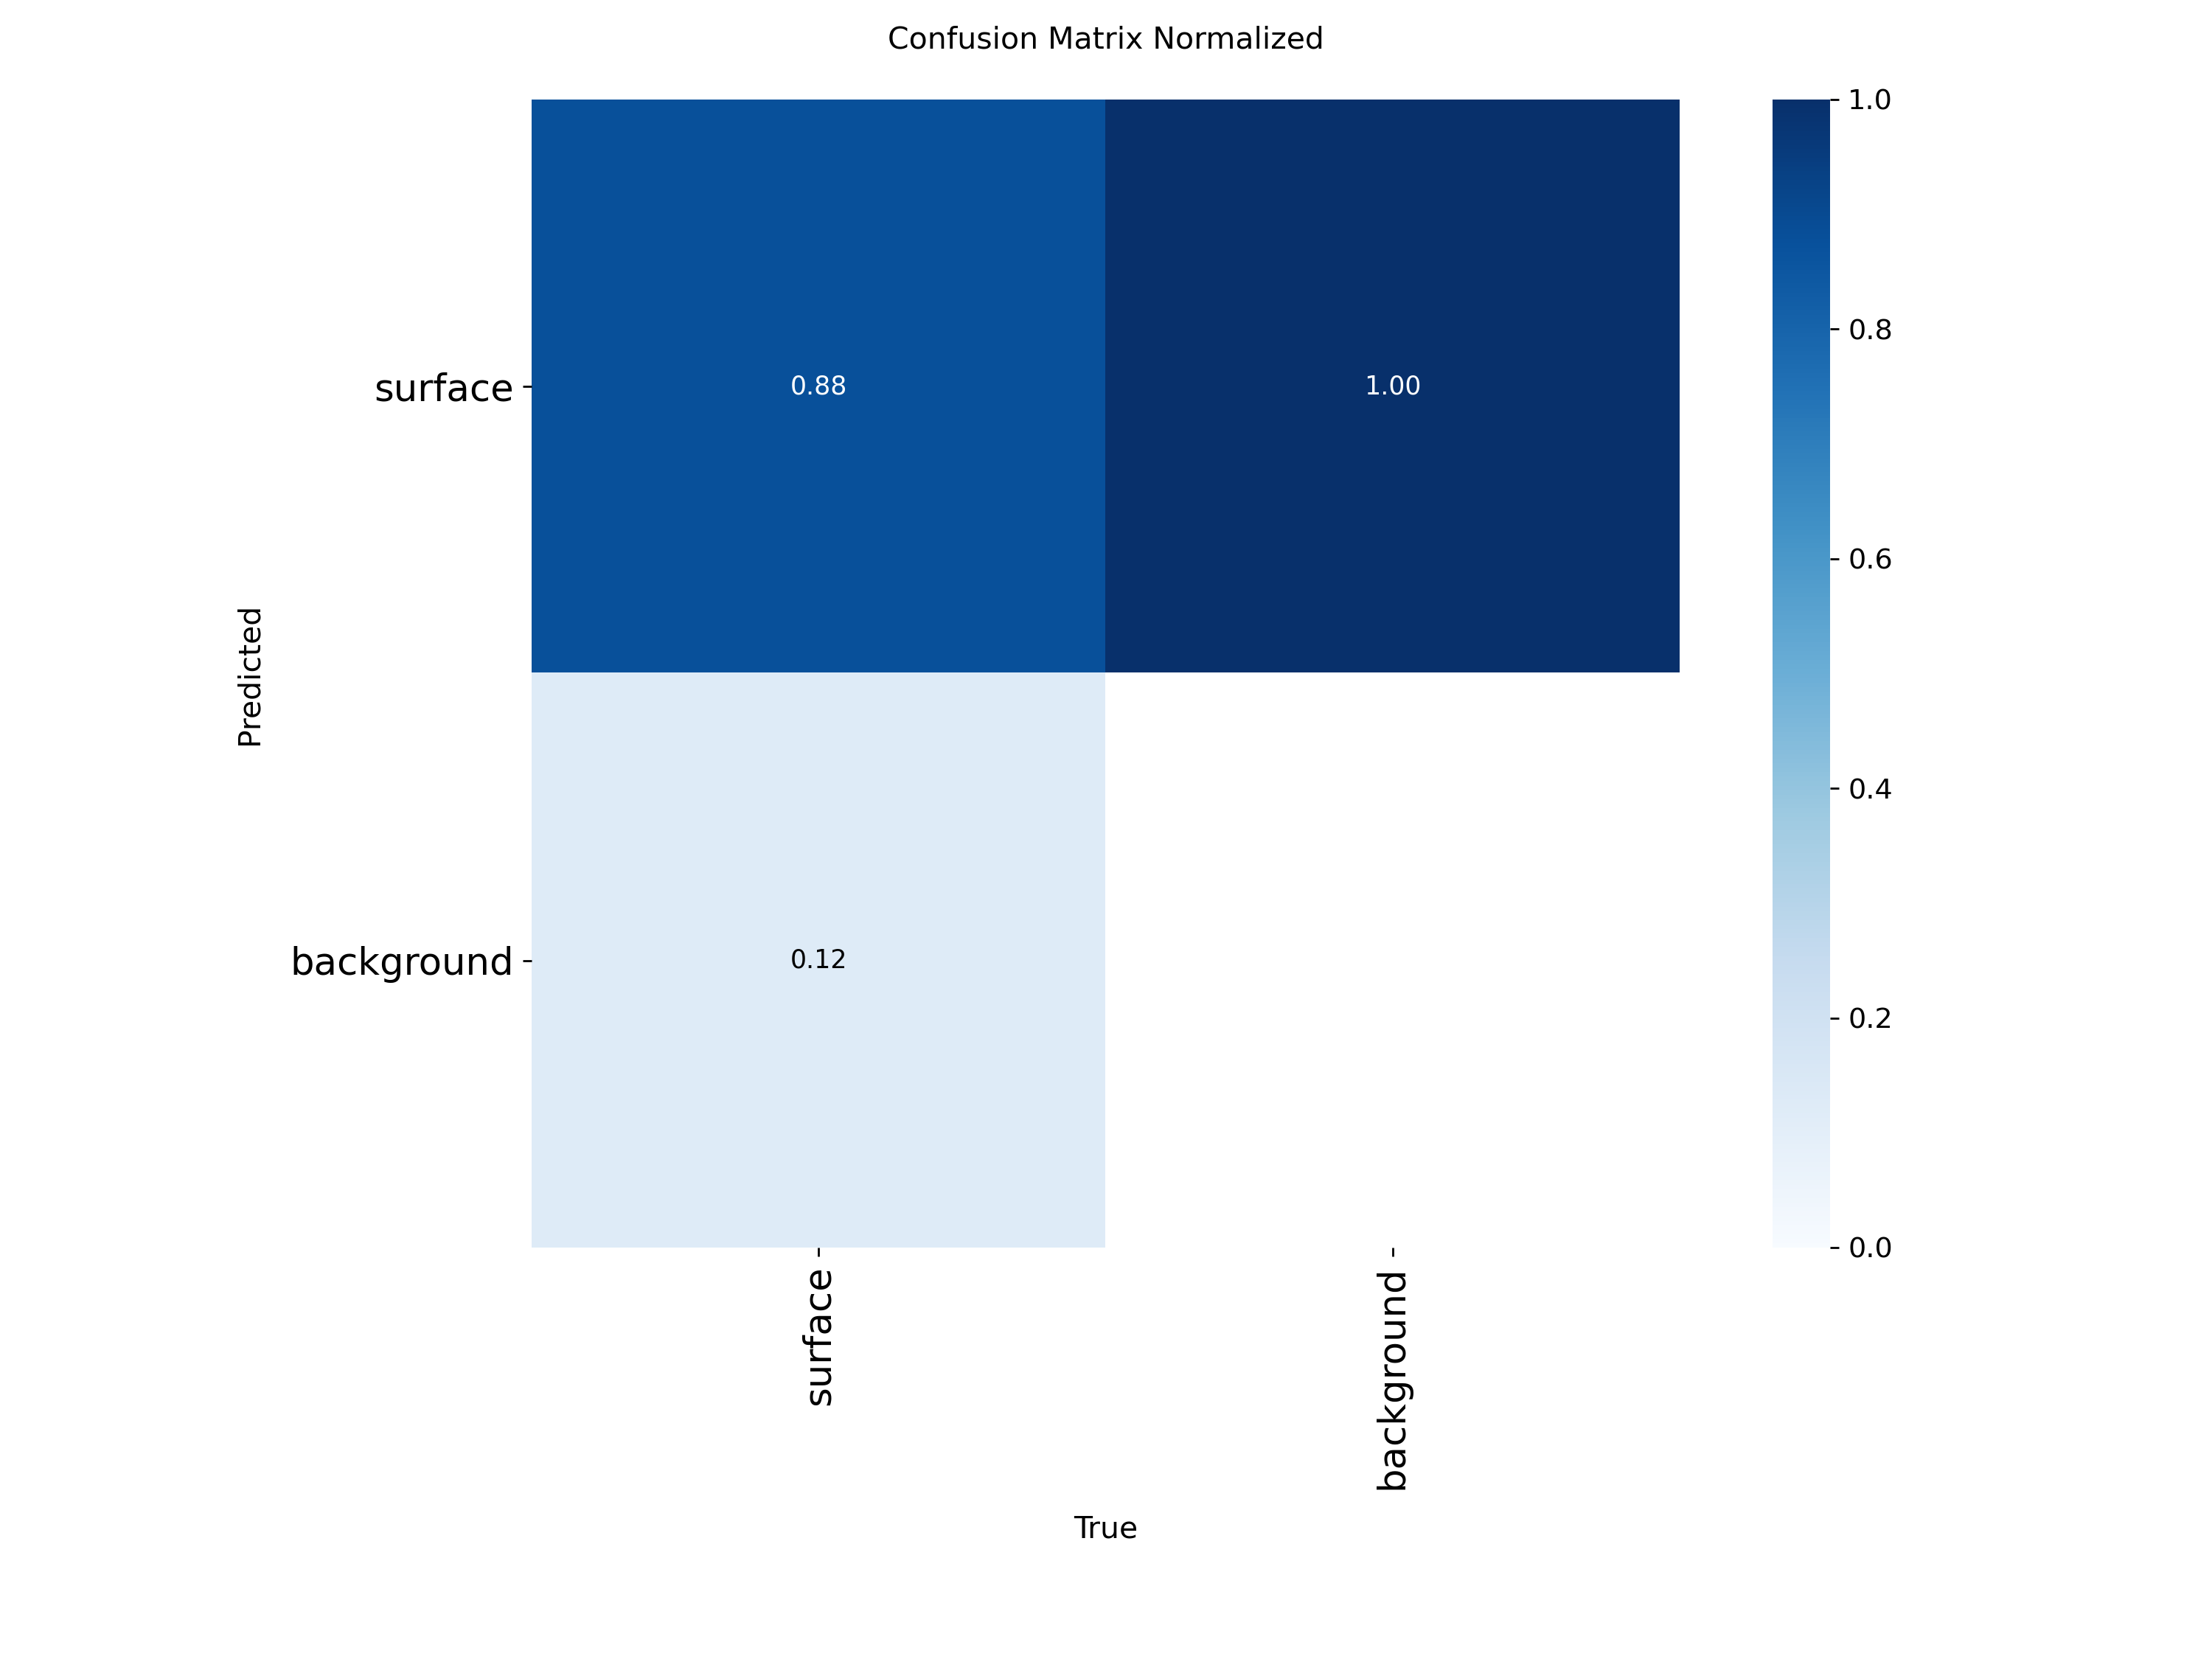

runs/segment/vesuvius_yolo11/results.png


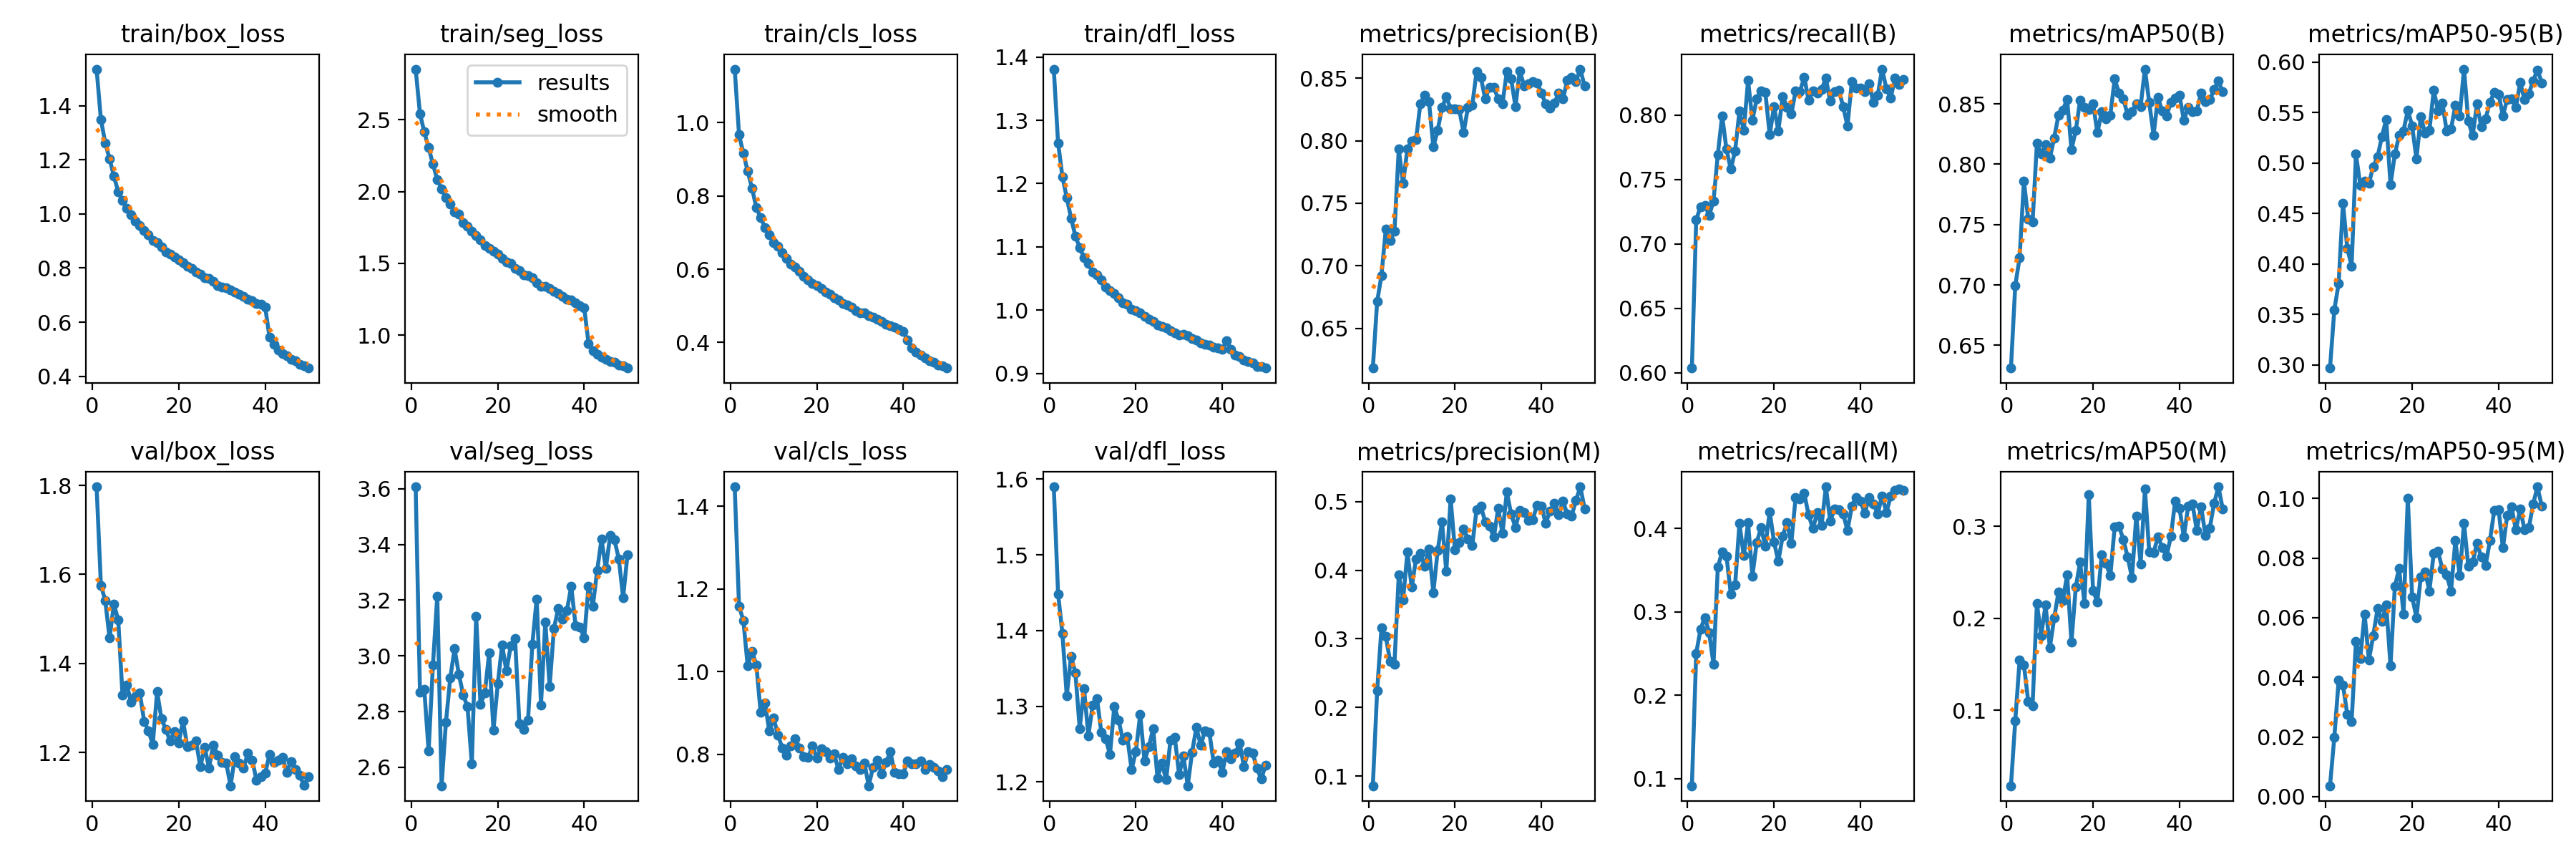

In [12]:
import glob
from IPython.display import Image, display

# Find the latest training run directory
runs_dir = 'runs/segment'

# Path to the results plot
for run_img in sorted(glob.glob(f'{runs_dir}/*/*.png')):
    print(run_img)
    display(Image(filename=run_img))

## 🔮 Inference

Predict on new 3D volumes...

In [13]:
from skimage.morphology import remove_small_objects, ball
import torch.nn.functional as F

def get_spherical_kernel(radius):
    """Generates a spherical kernel (structuring element) for 3D morphological operations."""
    # Generate boolean ball on CPU
    kernel_np = ball(radius)
    # Convert to float tensor: (1, 1, D, H, W)
    kernel = torch.from_numpy(kernel_np.astype(np.float32)).unsqueeze(0).unsqueeze(0)
    return kernel

def post_process_3d(
    volume: np.ndarray,
    min_size: int = 1000,
    closing_radius: int = 5,
    device: str = DEVICE,
) -> np.ndarray:
    """Applies 3D morphological operations to clean up a segmentation volume using a spherical element.

    Steps:
    1. Performs morphological closing (Dilation -> Erosion) with a spherical kernel.
    2. Removes small connected components.
    """
    # Ensure input is boolean
    binary_vol = volume > 0
    clean_vol_np = binary_vol

    # 1. Close gaps with Spherical Element (GPU accelerated)
    if closing_radius > 0:
        # print(f"Closing gaps with spherical radius {closing_radius} (GPU accelerated)...")
        # Prepare Input: (1, 1, D, H, W)
        input_tensor = torch.from_numpy(clean_vol_np.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
        # Prepare Kernel
        kernel = get_spherical_kernel(closing_radius).to(device)
        # Dilation: (Input * Kernel) > 0
        # We use padding=closing_radius to maintain the same spatial dimensions (same as 'same' padding)
        dilated = (F.conv3d(input_tensor, kernel, padding=closing_radius) > 0).float()
        # Erosion: 1 - ((1 - Dilated) * Kernel > 0)
        # This relies on the duality: Erosion(A) = ~Dilation(~A)
        eroded = 1.0 - (F.conv3d(1.0 - dilated, kernel, padding=closing_radius) > 0).float()
        # Retrieve result
        clean_vol_np = eroded.squeeze().cpu().numpy().astype(bool)

    # 2. Remove small objects (CPU-bound)
    # print(f"Removing small objects < {min_size} voxels (CPU-bound)...")
    clean_vol_np = remove_small_objects(clean_vol_np, min_size=min_size)

    return clean_vol_np.astype(np.uint8)

In [14]:
def predict_and_save_volume(volume_path, model, output_dir='.'):
    """Loads a volume, runs YOLO inference slice-by-slice, and saves the predicted mask volume."""
    base_name = Path(volume_path).stem
    # print(f"Processing volume: {base_name}...")
    volume = tifffile.imread(volume_path)
    depth, height, width = volume.shape
    predictions_list_2d = []

    # Iterate over all slices
    for i in tqdm(range(depth), desc=f"Slices for {base_name}", leave=False):
        img_slice = volume[i]
        # Preprocess: Normalize to uint8 (0-255) if needed
        if img_slice.dtype != np.uint8:
            img_slice = cv2.normalize(img_slice, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        # Convert to BGR for YOLO
        img_bgr = cv2.cvtColor(img_slice, cv2.COLOR_GRAY2BGR)
        # Run inference
        results = model.predict(img_bgr, verbose=False, retina_masks=True)
        result = results[0]

        # Initialize empty mask (background)
        mask_slice = np.zeros((height, width), dtype=np.uint8)
        if result.masks is not None:
            masks_tensor = result.masks.data
            if masks_tensor is not None:
                # Combine all detected masks
                combined_mask = torch.any(masks_tensor, dim=0).int().cpu().numpy()
                # Resize if needed
                combined_mask = cv2.resize(
                    combined_mask.astype(np.uint8), (width, height), interpolation=cv2.INTER_NEAREST)
                mask_slice = combined_mask.astype(np.uint8)
        predictions_list_2d.append(mask_slice)

    # Stack slices
    predictions_volume = np.stack(predictions_list_2d, axis=0).astype(np.uint8)
    predictions_volume = post_process_3d(
        predictions_volume, min_size=20*20*20, closing_radius=7)

    # Save volume
    output_filename = os.path.join(output_dir, f"{base_name}.tif")
    tifffile.imwrite(output_filename, predictions_volume)
    print(f"Saved prediction volume: {output_filename} (Shape: {predictions_volume.shape})")
    return output_filename

In [15]:
# Main Execution Block
test_images_dir = os.path.join(INPUT_DIR, 'test_images')
test_volume_files = [f for f in os.listdir(test_images_dir) if f.endswith('.tif')]
print(f"Found {len(test_volume_files)} test volumes.")

test_filenames = []
for test_volume_file in tqdm(test_volume_files, desc="Total Progress"):
    full_path = os.path.join(test_images_dir, test_volume_file)
    saved_file = predict_and_save_volume(full_path, model)
    test_filenames.append(saved_file)

print("All volumes processed.")

Found 1 test volumes.


Total Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Slices for 1407735:   0%|          | 0/320 [00:00<?, ?it/s]

Saved prediction volume: ./1407735.tif (Shape: (320, 320, 320))
All volumes processed.


Visualizing cuts for: 1407735.tif


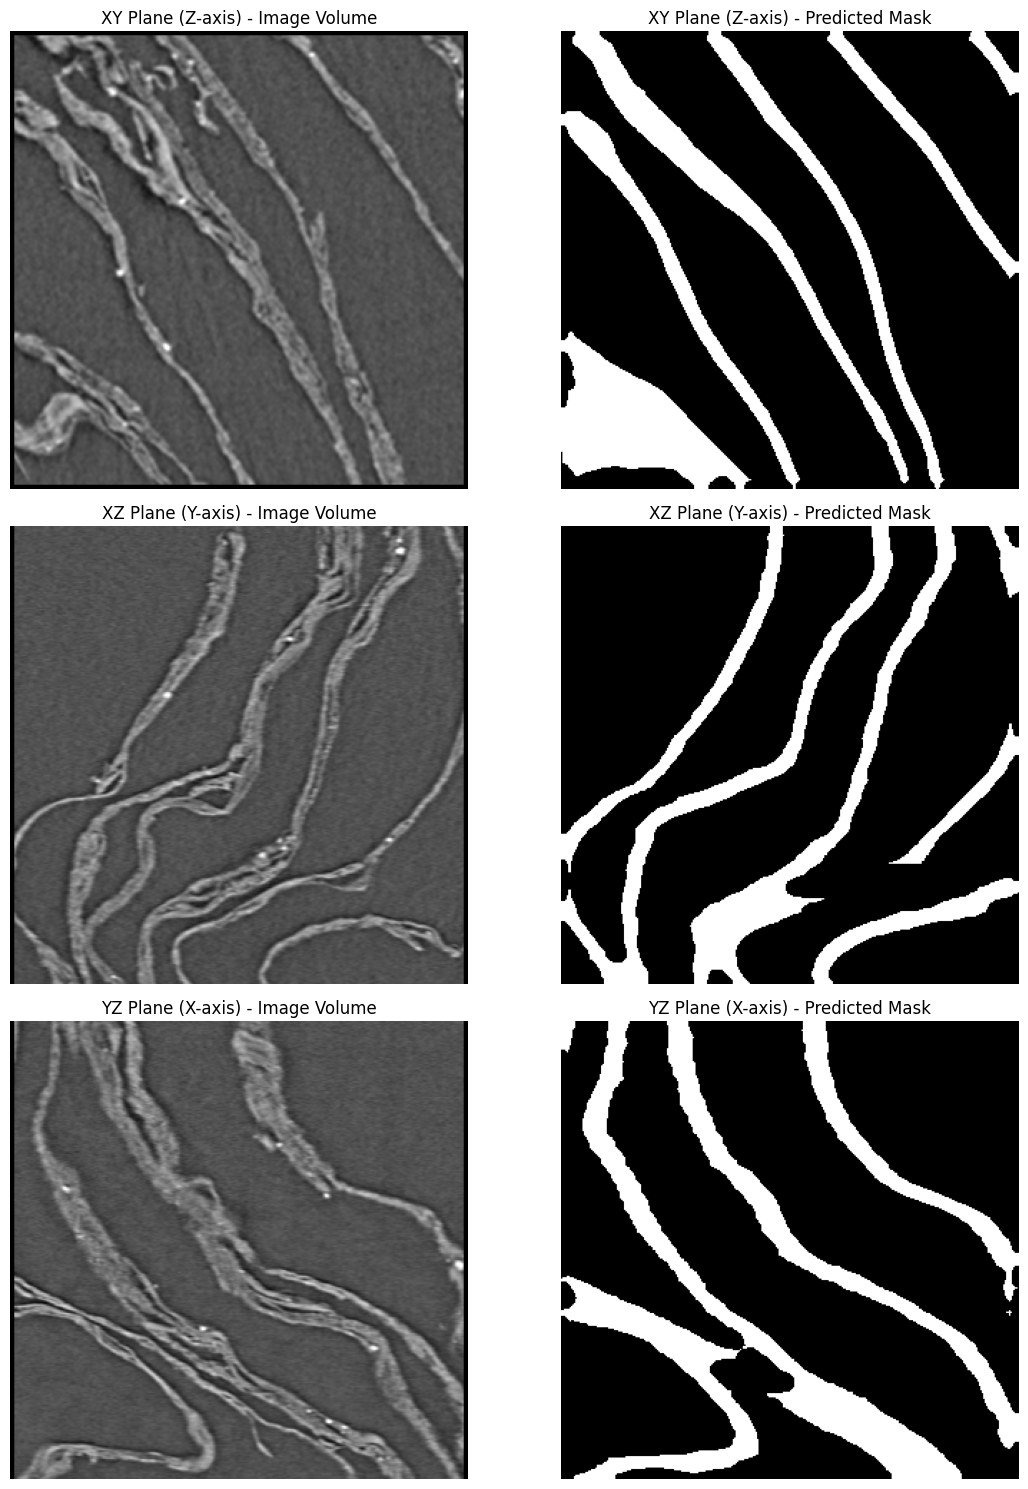

In [16]:
def plot_three_axis_cuts(image_vol_path, mask_vol_path):
    """Plots the middle slice of the XY, XZ, and YZ planes for both the image volume and the predicted mask."""
    print(f"Visualizing cuts for: {os.path.basename(image_vol_path)}")
    # Load volumes
    image_vol = tifffile.imread(image_vol_path)
    mask_vol = tifffile.imread(mask_vol_path)
    
    # Get dimensions
    d, h, w = image_vol.shape
    z_mid, y_mid, x_mid = d // 2, h // 2, w // 2
    
    # Extract slices
    slices = {
        'XY Plane (Z-axis)': (image_vol[z_mid, :, :], mask_vol[z_mid, :, :]),
        'XZ Plane (Y-axis)': (image_vol[:, y_mid, :], mask_vol[:, y_mid, :]),
        'YZ Plane (X-axis)': (image_vol[:, :, x_mid], mask_vol[:, :, x_mid])
    }
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    for i, (plane_name, (img_slice, mask_slice)) in enumerate(slices.items()):
        # Image Volume
        axes[i, 0].imshow(img_slice, cmap='gray')
        axes[i, 0].set_title(f"{plane_name} - Image Volume")
        axes[i, 0].axis('off')
        
        # Mask
        axes[i, 1].imshow(mask_slice, cmap='gray')
        axes[i, 1].set_title(f"{plane_name} - Predicted Mask")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Visualize the first processed volume
if test_filenames:
    # We assume test_volume_files and test_filenames are aligned from the previous loop
    # test_filenames contains the output paths we just saved
    # test_volume_files contains the original filenames in test_images_dir
    
    image_path = os.path.join(test_images_dir, test_volume_files[0])
    mask_path = test_filenames[0]
    
    plot_three_axis_cuts(image_path, mask_path)

### Export submission

In [17]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for filename in tqdm(test_filenames, desc="Zipping files"):
        if not os.path.exists(filename):
            print(f"Missing <> {filename}")
            continue
        zipf.write(filename)
        os.remove(filename)

Zipping files:   0%|          | 0/1 [00:00<?, ?it/s]